# Analysing simulation results (12 Aug 2026)

## Setup

In [1]:
# ── Environment switch: Colab or laptop ─────────────────────────────────────
# Mirrors 2a–2d so this notebook runs in the same two places they do. Without
# it, every path below ("results/...", "data/...") is resolved against whatever
# directory the kernel happened to start in — which is what a
# FileNotFoundError on results/option1_literature_summary.csv actually means:
# not a missing file, a wrong working directory.
import os, sys, subprocess, shutil
from pathlib import Path

RUNNING_LOCALLY = True   # False → Colab: force-fresh clone, then mount Drive
RUN_TAG         = 'full'  # which tier of the study to read: 'full' or 'smoke'
INSTALL_LATEX   = False   # True → apt-get TeX so text.usetex figures render (~3 min)

# Uses subprocess/os.chdir rather than !/% magics so the RUNNING_LOCALLY guard
# actually holds — a line magic fires regardless of the surrounding `if`
# (NOTEBOOK_WRITING_SKILL §5–6).
if not RUNNING_LOCALLY:
    COLAB_BASE = Path('/content')
    os.chdir(COLAB_BASE)
    repo_dir = COLAB_BASE / 'e_network_inequality'
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    subprocess.run(['git', 'clone', '-b', 'main',
                    'https://github.com/IgnacioOQ/e_network_inequality'], check=True)
    os.chdir(repo_dir)
    subprocess.run(['pip', 'install', '-q', 'python-dotenv'], check=True)
    if INSTALL_LATEX:
        # The plotting cells set text.usetex=True. Colab has no TeX, and
        # matplotlib fails at RENDER time rather than at import, so the error
        # surfaces from inside seaborn and reads like a plotting bug.
        subprocess.run(['apt-get', '-qq', 'install', '-y', 'texlive-latex-extra',
                        'texlive-fonts-recommended', 'dvipng', 'cm-super'], check=True)
else:
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'model').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

# Every figure cell below reads this. Set once, here, so a runtime without TeX
# degrades to mathtext instead of raising three cells later.
USETEX = RUNNING_LOCALLY or INSTALL_LATEX

print("Working dir:", REPO_ROOT)
print("text.usetex:", USETEX)

Working dir: /Users/heinduijf/GitHub/e_network_inequality
text.usetex: True


In [2]:
import os

import pandas as pd
import numpy as np
import networkx as nx
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore
import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from pathlib import Path
from dotenv import load_dotenv

load_dotenv()  # Loads from .env in project root
paper_fig_dir = os.getenv('PAPER_FIG_DIR')

### Plot style: opinionated

Use [opinionated](https://github.com/MNoichl/opinionated)'s `opinionated_rc` theme (Roboto Condensed) throughout the figures. It is installed with the project dependencies. Font sizes are reduced for the compact panels; the numerical analyses and condition colors are unchanged.

In [3]:
from importlib.util import find_spec as opinionated_find_spec

# opinionated 0.0.3.0 checks ./fonts at import time. Import from its installed
# package directory so it uses the bundled fonts without downloading them again.
opinionated_package = opinionated_find_spec('opinionated')
if opinionated_package is None:
    raise ImportError('Install the project dependencies with uv sync before running this notebook.')
opinionated_previous_directory = Path.cwd()
try:
    os.chdir(Path(opinionated_package.origin).parent)
    import opinionated
finally:
    os.chdir(opinionated_previous_directory)
    
import colormaps as cmaps 


OPINIONATED_STYLE = 'opinionated_rc'
OPINIONATED_SMALL_PLOT_RC = {}  # Optional overrides are disabled.
# OPINIONATED_SMALL_PLOT_RC = {
#     'text.usetex': False,  # Matplotlib renders the theme's bundled fonts directly.
#     'font.size': 9.75, 'axes.titlesize': 10.5, 'axes.labelsize': 9.75,
#     'xtick.labelsize': 9, 'ytick.labelsize': 9, 'axes.titlepad': 8,
# }
plt.style.use(OPINIONATED_STYLE)
# plt.rcParams.update(OPINIONATED_SMALL_PLOT_RC)
print(f'Plot style: {OPINIONATED_STYLE} (opinionated {opinionated.__version__})')

Plot style: opinionated_rc (opinionated 0.0.3.0)


/Users/heinduijf/GitHub/e_network_inequality/.venv/lib/python3.10/site-packages/opinionated/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Where the summary CSVs come from

`2a`/`2b`/`2c` bank their shards on Drive and `2d` aggregates them into `<option>_summary.csv` under `notebook3_inputs/<RUN_TAG>/`. Two of those files (`option1`, `option3`) are also committed to the repo's `results/`; a freshly aggregated one exists **only on Drive** until someone copies it across.

The loader checks Drive first, then the repo, and prints which it used.

The original Option 1–3 sections below retain these historical sources. The **combined analysis at the bottom** loads the new, git-ignored `data/equality_study/` dataset and reports download completeness separately.

In [4]:
# The same environment split as 2a–2d — one path constant, defined once.
if RUNNING_LOCALLY:
    STUDY_ROOT = Path('results/equality_study')
else:
    from google.colab import drive
    drive.mount('/content/drive')
    STUDY_ROOT = Path('/content/drive/My Drive/Colab Projects/Data Driven ABMs/'
                      'Data Sets/equality_study')

# Two places a summary can be, checked in this order:
#   1. Drive, where 2d just wrote it — the only place a newly aggregated option
#      exists, and always the freshest copy of one that is still growing
#   2. the repo's results/ — where option1 and option3 are committed
# Second is a fallback, not a duplicate: without it, option1/option3 would stop
# loading on any runtime where Drive is not mounted.
SUMMARY_SEARCH_PATH = [
    STUDY_ROOT / 'notebook3_inputs' / RUN_TAG,
    REPO_ROOT / 'results',
    STUDY_ROOT
]

# Figures: the Colab clone is discarded with the runtime, so writing them into
# ./results/ there loses them silently. Drive persists; the repo does locally.
FIGURE_DIR = REPO_ROOT / 'results' / 'figures' if RUNNING_LOCALLY else STUDY_ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Looking for summaries in:")
for directory in SUMMARY_SEARCH_PATH:
    print(f"  {'OK     ' if directory.is_dir() else 'absent '} {directory}")
print("Figures ->", FIGURE_DIR)


def load_summary(slug):
    """Load one option's variant summary from wherever it actually is.

    Also reports completeness when 2d wrote it. A partial arm produces a
    perfectly ordinary regression — nothing downstream would mention that a
    network is at 68% of its target — so the one chance to notice is at load.
    """
    name = 'variant_summary_combined.csv'
    candidate = STUDY_ROOT / name
    if candidate.exists():
        df = pd.read_csv(candidate)
        df = df[df['difficulty'] == slug]
        return df

    name = f'{slug}_summary.csv'
    for directory in SUMMARY_SEARCH_PATH:
        candidate = directory / name
        if not candidate.exists():
            continue
        df = pd.read_csv(candidate)
        print(f"Loaded {name}: {len(df):,} rows from {directory}")
        print(df['network'].value_counts().to_string())

        completeness = directory / 'completeness.csv'
        if completeness.exists():
            report = pd.read_csv(completeness)
            partial = report[(report['option'] == slug) & (report['complete'] == False)]  # noqa: E712
            for row in partial.itertuples():
                print(f"  !!! PARTIAL — {row.network}/{row.method}: "
                      f"{row.variants_summarised:,} of {row.variants_target:,} ({row.pct}%)")
        return df

    tried = '\n'.join(f'    {d / name}' for d in SUMMARY_SEARCH_PATH)
    raise FileNotFoundError(
        f"{name} is in none of the searched locations:\n{tried}\n"
        "  Run 2d. GColab Simulations Equality - Aggregation.ipynb to produce it, "
        "or check RUN_TAG.")

Looking for summaries in:
  absent  results/equality_study/notebook3_inputs/full
  OK      /Users/heinduijf/GitHub/e_network_inequality/results
  OK      results/equality_study
Figures -> /Users/heinduijf/GitHub/e_network_inequality/results/figures


### Rename dict

In [5]:
rename_dict = {
    'uncertainty': 'Problem Easiness',
    'n_experiments': 'Number of Experiments',
    'share_of_correct_agents_at_convergence':'Share of correct agents',
    'mean_share_of_correct_agents_at_convergence':'Share of correct agents (mean)',
    'degree_average': 'Mean Degree',
    'average_degree': 'Average Degree',
    'clustering_average':'Clustering Coeff.',
    'approx_average_clustering_coefficient':'Clustering Coeff.',
    'degree_gini':'Degree Gini Coeff.',
    'degree_gini_coefficient': 'Degree Gini Coeff.',
}

### Methods for statistics

In [6]:
def VIF_interpretation(score: float) -> str:
    if score >= 5:
        return "high multicollinearity"
    elif score > 1.5:
        return "acceptable multicollinearity"
    elif score > 1:
        return "minimal multicollinearity"
    elif score == 1:
        return "no multicollinearity"
    else:
        return "something went wrong"


def compute_vif(
    df: pd.DataFrame,
    columns_corr: list[str] = [
        "degree_average", "degree_gini", "clustering_average"
    ],
    rename_dict:dict[str,str] = rename_dict
) -> pd.DataFrame:
    X = df[columns_corr].copy()
    X_const = X
    X_const = sm.add_constant(X)

    vif_data = pd.DataFrame(
        {
            "variable": X_const.columns,
            "VIF": [
                variance_inflation_factor(X_const.values, i)
                for i in range(X_const.shape[1])
            ],
            "VIF interpretation": [
                VIF_interpretation(variance_inflation_factor(X_const.values, i))
                for i in range(X_const.shape[1])
            ],
        }
    )
    vif_df = pd.DataFrame(
        vif_data, 
        columns=["variable", "VIF", "VIF interpretation"])
    vif_df = vif_df[vif_df["variable"].isin(columns_corr)]
    vif_df = vif_df.set_index("variable")
    return vif_df.rename(rename_dict)

def pearson_interpretation(
      score: float
) -> str:
    score_abs = abs(score)
    if score_abs <= 0.1:
        return "insignificant"
    elif score_abs <= 0.3:
        return "weak"
    elif score_abs <= 0.5:
        return "medium"
    elif score_abs <= 1:
        return "strong"
    else:
        return "error"

def compute_correlations(
    df: pd.DataFrame,
    columns_corr=["degree_average", "degree_gini", "clustering_average"],
    rename_dict: dict[str,str]=rename_dict,
) -> pd.DataFrame:
    df_corr = df[columns_corr].corr(method="pearson")
    df_corr_interpretation = df_corr.map(pearson_interpretation)

    mask = np.triu(np.ones(df_corr.shape, dtype=bool), k=1)

    result = (
        df_corr.where(mask)
        .stack()
        .rename("correlation")
        .to_frame()
    )
    result["interpretation"] = df_corr_interpretation.where(mask).stack()
    result.index.names = ["variable 1", "variable 2"]
    result = result.sort_values("correlation", key=abs, ascending=False)
    return result.dropna(how="all").rename(rename_dict)


In [7]:
def linear_regression(
        results_df: pd.DataFrame,
        predictors: list[str]=[
            "degree_gini_coefficient",
            "approx_average_clustering_coefficient",
        ],
        dependent_variable: str="mean_share_of_correct_agents_at_convergence",
        print_results: bool = True,
        print_full_summary: bool = True,
        return_latex: bool = False,
        latex_caption: str | None = None,
        latex_label: str = "tab:regression_results",
        latex_decimals: int = 3,
        return_stats: bool = False,
    ):
    # Get data
    X = results_df[predictors]
    y = results_df[[dependent_variable]].rename(columns=rename_dict)

    network = results_df["network"].iloc[0]

    # Add constant and fit model
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()

    # Compute descriptive statistics
    stats = (X.select_dtypes(include='number')
                .agg(['mean', 'std', 'min', 'max'])     # sample std (ddof=1)
                .T
                .rename(columns={'mean':'Mean', 'std':'Std', 'min': 'Min', 'max': 'Max'}))


    # p-values
    p_values = model.pvalues[1:]

    # Effect size (Cohen's f^2)
    # Cohen’s rules of thumb: 0.02 (small), 0.15 (medium), 0.35 (large).
    r2_full = model.rsquared
    f2_values = []
    for col in X.columns:
        X_reduced = X.drop(columns=[col])
        X_reduced = sm.add_constant(X_reduced)
        model_reduced = sm.OLS(y, X_reduced).fit()
        r2_reduced = model_reduced.rsquared
        f2 = (r2_full - r2_reduced) / (1 - r2_full)
        f2_values.append(f2)
    f_squared = pd.Series(f2_values, index=X.columns)

    f_squared = (model.tvalues[1:] ** 2) / model.df_resid

    def interpret_f2(f2):
        if f2 >= 0.35:
            return 'Large'
        elif f2 >= 0.15:
            return 'Medium'
        elif f2 >= 0.02:
            return 'Small'
        else:
            return 'Negligible'

    # Compute standardized coefficients
    # Standardize using zscore, and fit on standardized data
    X_std = zscore(X, ddof=1)
    y_std = zscore(y, ddof=1)
    model_std = sm.OLS(y_std, sm.add_constant(X_std)).fit()
    coef_normalized = model_std.params[1:]

    predictors_df = pd.DataFrame({
        'Normalized Coef': coef_normalized,
        'f²': f_squared,
        'f² Interpretation': f_squared.apply(interpret_f2),
        'p-value': model.pvalues[1:].round(4),
    }, index=X.columns)
    predictors_df = predictors_df.sort_values(by='f²', ascending=False)

    columns_corr = [
    "degree_gini_coefficient",
    "approx_average_clustering_coefficient",
    ]
    # for df in [df_pud, df_tobacco, df_ego]:

    df_correlations = compute_correlations(
        df=results_df,
        columns_corr=columns_corr
    )
    df_vif = compute_vif(
        df=results_df,
        columns_corr=columns_corr
    )
    def check(text) -> str:
        if "weak" in text or "minimal" in text or "insignificant" in text:
            return True
        return False
    symbol = "❌"
    if df_correlations["interpretation"].map(check).all() and df_vif["VIF interpretation"].map(check).all():
        symbol = "✅"
    if print_results:
        print("="*60)
        print(f'🔍 {network.upper()} — Linear Regression — Short Summary')
        print("="*60)
        print(f"R² = {round(model.rsquared, 3)} (coefficient of determination)")
        print(f"{symbol} VIF and Pearson correlations were minimal, insignificant and/or weak")
        display(predictors_df.rename(rename_dict))
        print("="*60)
        if print_full_summary:
            print('-'*60)
            print('Descriptive Statistics')
            print('-'*60)
            print(f'- The length of the data is: {len(results_df):,}')
            display(stats)
            print("-"*60)
            print('Collinearity results')
            print("-"*60)
            display(df_correlations)
            display(df_vif)
            print('-'*60)
            print('Full Summary')
            print('-'*60)
            print(model.summary())

    # Standardized-model stats, keyed by predictor position (0 = const), so they
    # can be looked up without relying on labels — zscore() returns a plain
    # ndarray, so model_std.params/bse/pvalues carry no column names.
    reg_stats = {
        "column_label": str(network),
        "dependent_label": y.columns[0],
        "predictors": list(X.columns),
        "predictor_positions": {col: i for i, col in enumerate(X.columns)},
        "params": np.asarray(model_std.params),
        "bse": np.asarray(model_std.bse),
        "pvalues": np.asarray(model_std.pvalues),
        "nobs": int(model_std.nobs),
        "rsquared": model_std.rsquared,
        "rsquared_adj": model_std.rsquared_adj,
        "resid_se": float(np.sqrt(model_std.mse_resid)),
        "df_resid": int(model_std.df_resid),
        "fvalue": model_std.fvalue,
        "f_pvalue": model_std.f_pvalue,
        "df_model": int(model_std.df_model),
    }

    latex_code = None
    if return_latex:
        latex_code = regression_stats_to_latex(
            {reg_stats["column_label"]: reg_stats},
            predictor_order=predictors,
            decimals=latex_decimals,
            caption=latex_caption,
            label=latex_label,
        )
        if print_results:
            print('-'*60)
            print('LaTeX table')
            print('-'*60)
            print(latex_code)

    if return_latex:
        return latex_code

    if return_stats:
        return reg_stats

    if not print_results and not print_full_summary:
        return model

In [8]:
def regression_stats_to_latex(
        models: dict[str, dict],
        predictor_order: list[str] | None = None,
        decimals: int = 3,
        caption: str | None = None,
        label: str = "tab:regression_results",
        column_labels: dict[str, str] | None = None,
        show_df: bool = True,
    ) -> str:
    """Build a stargazer-style threeparttable from one or more `linear_regression(..., return_stats=True)` results."""

    def stars(p: float) -> str:
        if p < 0.001:
            return "^{***}"
        elif p < 0.01:
            return "^{**}"
        elif p < 0.05:
            return "^{*}"
        return ""

    def fmt(x: float) -> str:
        return f"{x:.{decimals}f}"

    column_keys = list(models.keys())
    column_labels = column_labels or {}
    display_labels = [column_labels.get(key, key) for key in column_keys]
    n_cols = len(column_keys)

    if predictor_order is None:
        predictor_order = []
        for reg_stats in models.values():
            for predictor in reg_stats["predictors"]:
                if predictor not in predictor_order:
                    predictor_order.append(predictor)

    dependent_labels = sorted({reg_stats["dependent_label"] for reg_stats in models.values()})
    dependent_label = dependent_labels[0] if len(dependent_labels) == 1 else " / ".join(dependent_labels)

    body_lines = []
    for predictor in predictor_order:
        row_label = rename_dict.get(predictor, predictor)
        coef_cells, se_cells = [], []
        for key in column_keys:
            reg_stats = models[key]
            if predictor in reg_stats["predictor_positions"]:
                idx = reg_stats["predictor_positions"][predictor] + 1  # +1 skips the constant
                coef = reg_stats["params"][idx]
                se = reg_stats["bse"][idx]
                p = reg_stats["pvalues"][idx]
                coef_cells.append(f"${fmt(coef)}{stars(p)}$")
                se_cells.append(f"({fmt(se)})")
            else:
                coef_cells.append("")
                se_cells.append("")
        body_lines.append(f"    {row_label} & " + " & ".join(coef_cells) + " \\\\")
        body_lines.append("    & " + " & ".join(se_cells) + " \\\\")

    stat_lines = [
        "    Observations & " + " & ".join(f"{models[k]['nobs']:,}" for k in column_keys) + " \\\\",
        "    $R^{2}$ & " + " & ".join(fmt(models[k]['rsquared']) for k in column_keys) + " \\\\",
        "    Adjusted $R^{2}$ & " + " & ".join(fmt(models[k]['rsquared_adj']) for k in column_keys) + " \\\\",
        "    Residual Std. Error & " + " & ".join(fmt(models[k]['resid_se']) for k in column_keys) + " \\\\",
    ]
    if show_df:
        stat_lines.append(
            "    & " + " & ".join(f"(df = {models[k]['df_resid']})" for k in column_keys) + " \\\\"
        )
    stat_lines.append(
        "    F Statistic & " + " & ".join(
            f"${fmt(models[k]['fvalue'])}{stars(models[k]['f_pvalue'])}$" for k in column_keys
        ) + " \\\\"
    )
    if show_df:
        stat_lines.append(
            "    & " + " & ".join(
                f"(df = {models[k]['df_model']}; {models[k]['df_resid']})" for k in column_keys
            ) + " \\\\"
        )

    col_spec = "l" + "c" * n_cols

    lines = ["\\begin{table}[!htbp]", "    \\centering"]
    if caption:
        lines.append(f"    \\caption{{{caption}}}")
        lines.append(f"    \\label{{{label}}}")
    lines.append("    \\begin{threeparttable}")
    lines.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    lines.append("    \\toprule")
    lines.append(f"     & \\multicolumn{{{n_cols}}}{{c}}{{\\textit{{Dependent variable: {dependent_label}}}}} \\\\")
    lines.append("    \\midrule")
    if n_cols > 1:
        lines.append("     & " + " & ".join(display_labels) + " \\\\")
        lines.append("    \\midrule")
    lines.extend(body_lines)
    lines.append("    \\midrule")
    lines.extend(stat_lines)
    lines.append("    \\bottomrule")
    lines.append("    \\end{tabular}")
    lines.append("    \\begin{tablenotes}")
    lines.append("    \\small")
    lines.append("    \\item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001")
    lines.append("    \\end{tablenotes}")
    lines.append("    \\end{threeparttable}")
    lines.append("\\end{table}")

    return "\n".join(lines)

In [90]:
def regression_stats_to_latex_horizontal(
        models: dict[str, dict],
        row_info: dict[str, tuple[str, str]],
        row_order: list[str] | None = None,
        predictor_order: list[str] | None = None,
        decimals: int = 3,
        caption: str | None = None,
        label: str = "tab:regression_results_horizontal",
    ) -> str:
    """Horizontal companion to `regression_stats_to_latex`: one row per model, predictors as
    columns, instead of one column per model and predictors as rows. `row_info` maps each key in
    `models` to (network_label, difficulty_label); consecutive rows sharing a network label are
    grouped under one \\multirow cell, as in the attached "Table 5" example. Requires
    \\usepackage{multirow} in the LaTeX preamble, alongside threeparttable/booktabs."""

    def stars(p: float) -> str:
        if p < 0.001:
            return "^{***}"
        elif p < 0.01:
            return "^{**}"
        elif p < 0.05:
            return "^{*}"
        return ""

    def fmt(x: float) -> str:
        return f"{x:.{decimals}f}"

    row_order = row_order or list(models.keys())

    if predictor_order is None:
        predictor_order = []
        for reg_stats in models.values():
            for predictor in reg_stats["predictors"]:
                if predictor not in predictor_order:
                    predictor_order.append(predictor)
    predictor_labels = [rename_dict.get(predictor, predictor) for predictor in predictor_order]

    # Consecutive rows sharing a network label become one \multirow group.
    group_sizes = []
    for key in row_order:
        network_label, _ = row_info[key]
        if group_sizes and group_sizes[-1][0] == network_label:
            group_sizes[-1][1] += 1
        else:
            group_sizes.append([network_label, 1])

    body_lines = []
    group_iter = iter(group_sizes)
    remaining_in_group = 0
    for key in row_order:
        network_label, difficulty_label = row_info[key]
        if remaining_in_group == 0:
            _, remaining_in_group = next(group_iter)
            network_cell = f"\\multirow{{{remaining_in_group}}}{{*}}{{{network_label}}}"
        else:
            network_cell = ""
        remaining_in_group -= 1

        reg_stats = models[key]
        cells = [network_cell, difficulty_label]
        for predictor in predictor_order:
            if predictor in reg_stats["predictor_positions"]:
                idx = reg_stats["predictor_positions"][predictor] + 1  # +1 skips the constant
                coef = reg_stats["params"][idx]
                se = reg_stats["bse"][idx]
                p = reg_stats["pvalues"][idx]
                cells.append(f"${fmt(coef)}{stars(p)}$ ({fmt(se)})")
            else:
                cells.append("")
        cells.append(f"{reg_stats['nobs']:,}")
        cells.append(fmt(reg_stats["rsquared"]))
        cells.append(fmt(reg_stats["rsquared_adj"]))
        cells.append(f"${fmt(reg_stats['fvalue'])}{stars(reg_stats['f_pvalue'])}$")
        body_lines.append("    " + " & ".join(cells) + " \\\\")

    col_spec = "ll" + "c" * len(predictor_order) + "cccc"
    header_cells = ["Network", "Difficulty", *predictor_labels, "Obs.", "$R^{2}$", "$R^{2}$ (adj.)", "F Statistic"]

    # Factor the residual/model df into one note, as in the attached example, when every
    # row shares them; otherwise the per-row F statistic alone still stands on its own.
    df_resid_values = {models[key]["df_resid"] for key in row_order}
    df_model_values = {models[key]["df_model"] for key in row_order}
    df_note = None
    if len(df_resid_values) == 1 and len(df_model_values) == 1:
        df_resid = df_resid_values.pop()
        df_model = df_model_values.pop()
        df_note = f"Residual df = {df_resid} for all models; F-test df = ({df_model}, {df_resid})."

    lines = ["\\begin{table}[!htbp]", "    \\centering"]
    if caption:
        lines.append(f"    \\caption{{{caption}}}")
        lines.append(f"    \\label{{{label}}}")
    lines.append("    \\begin{threeparttable}")
    lines.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    lines.append("    \\toprule")
    lines.append("    " + " & ".join(header_cells) + " \\\\")
    lines.append("    \\midrule")
    lines.extend(body_lines)
    lines.append("    \\bottomrule")
    lines.append("    \\end{tabular}")
    lines.append("    \\begin{tablenotes}")
    lines.append("    \\small")
    if df_note:
        lines.append(f"    \\item {{}} {df_note}")
    lines.append("    \\item {} Standard errors in parentheses.")
    lines.append("    \\item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001")
    lines.append("    \\end{tablenotes}")
    lines.append("    \\end{threeparttable}")
    lines.append("\\end{table}")

    return "\n".join(lines)

### Methods for plots

In [9]:
def save_figure_in_paper_fig_dir(
    filename, *args, **kwargs
):
    """
    Saves a figure in the paper_fig_dir directory.

    Skips instead of raising when PAPER_FIG_DIR is unset or missing: it comes
    from a .env that exists on the laptop where the paper is written and not on
    a Colab runtime, and a figure that has already been written to FIGURE_DIR
    should not be turned into an exception by the copy to a second location.
    """
    if paper_fig_dir is None:
        print("  (PAPER_FIG_DIR unset — not copying to the paper directory)")
        return
    if not os.path.exists(Path(paper_fig_dir).expanduser()):
        print(f"  (PAPER_FIG_DIR '{paper_fig_dir}' does not exist — not copying)")
        return
    fig_path = Path(paper_fig_dir).expanduser() / filename
    plt.savefig(fig_path, *args, **kwargs)

In [10]:
def plot_linear_regression(
        df: pd.DataFrame,
        x: str = "degree_gini_coefficient",
        y: str = "mean_share_of_correct_agents_at_convergence",
        title: str = "Linear Regression",
        filename: str | None = None,
        show_plot: bool = True,
):
    plt.style.use(OPINIONATED_STYLE)
    plt.rcParams.update(OPINIONATED_SMALL_PLOT_RC)
    plt.figure(figsize=(2.2, 2.2))
    
    fig = sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter=True,
        scatter_kws={"s": 10, "alpha": 0.5, "color":"lightgray"},
        line_kws={"color": "black"},
    )
    
    x_label = rename_dict.get(x, x)
    y_label = rename_dict.get(y, y)
    fig.set_xlabel(x_label)
    fig.set_ylabel(y_label)

    x_values = df["degree_gini_coefficient"].values
    y_values = df["mean_share_of_correct_agents_at_convergence"].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, y_values)
    fig.set_title(f"{title} ($R^2={r_value**2:.3f}$)")
    if filename:
        plt.savefig(
            FIGURE_DIR / f"{filename}.png",  # Drive on Colab; the clone does not survive
            bbox_inches="tight",
            dpi=800,
            format="png",
        )
        save_figure_in_paper_fig_dir(
            f"{filename}.png",
            bbox_inches="tight",
            dpi=800,
            format="png",
        )

    if show_plot:
        plt.show()


In [11]:
def plot_multiple_linear_regressions(
        dfs: list[pd.DataFrame],
        titles: list[str],
        x: str = "degree_gini_coefficient",
        y: str = "mean_share_of_correct_agents_at_convergence",
        filename: str | None = None,
        show_plot: bool = True,
):
    plt.style.use(OPINIONATED_STYLE)
    plt.rcParams.update(OPINIONATED_SMALL_PLOT_RC)

    # A4 page (210 x 297 mm) minus 1 inch margins on every side.
    a4_width_in = 210 / 25.4
    margin_in = 1.0
    fig_width = a4_width_in - 2 * margin_in
    fig_height = fig_width / len(dfs)

    fig, axes = plt.subplots(
        1, len(dfs), figsize=(fig_width, fig_height), constrained_layout=True
    )

    x_label = rename_dict.get(x, x)
    y_label = rename_dict.get(y, y)

    for i, (ax, df, title) in enumerate(zip(axes, dfs, titles)):
        sns.regplot(
            data=df,
            x=x,
            y=y,
            ax=ax,
            scatter=True,
            scatter_kws={"s": 10, "alpha": 0.5, "color": "lightgray"},
            line_kws={"color": "black"},
        )
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label if i == 0 else "")
        ax.set_title(title)

        slope, intercept, r_value, p_value, std_err = stats.linregress(df[x].values, df[y].values)
        ax.text(
            0.95, 0.95, f"$R^2 = {r_value**2:.3f}$",
            transform=ax.transAxes,
            ha="right", va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="lightgray", alpha=0.85),
        )

    if filename:
        plt.savefig(
            f"./results/{filename}.png",
            bbox_inches="tight",
            dpi=800,
            format="png",
        )
        save_figure_in_paper_fig_dir(
            f"{filename}.png",
            bbox_inches="tight",
            dpi=800,
            format="png",
        )

    if show_plot:
        plt.show()

## Easy problems ($\varepsilon = 0.1$)

### Load csv and create dataframes

⚠️ Note: Depending on the details of the simulation study, you might have to include `uncertainty` and/or `n_experiments` as predictors.

In [55]:
df_summary = load_summary(slug="easy")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient",
] # "uncertainty", "n_experiments"]

In [56]:
print(df_pud["n_experiments"].value_counts())
uncertainty_values = df_pud["uncertainty"].values
print(f"Problem Easiness.\n\t Min: {min(uncertainty_values):.5f}\n\t Max: {max(uncertainty_values):.5f}")

n_experiments
1000    1000
Name: count, dtype: int64
Problem Easiness.
	 Min: 0.10000
	 Max: 0.10000


### Linear regressions: Short summaries

In [57]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.236 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.469474,0.283725,Medium,0.0000
Clustering Coeff.,0.078804,0.007994,Negligible,0.0049


🔍 TOBACCO — Linear Regression — Short Summary
R² = 0.692 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.830247,2.236252,Large,0.000
Clustering Coeff.,-0.029563,0.002835,Negligible,0.093


🔍 EGO — Linear Regression — Short Summary
R² = 0.012 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.110122,0.012046,Negligible,0.0006
Clustering Coeff.,0.033545,0.001118,Negligible,0.2914


### Linear regressions: Full overview

In [58]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.236 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.469474,0.283725,Medium,0.0000
Clustering Coeff.,0.078804,0.007994,Negligible,0.0049


------------------------------------------------------------
Descriptive Statistics
------------------------------------------------------------
- The length of the data is: 1,000


,Mean,Std,Min,Max
degree_gini_coefficient,0.707882,0.013702,0.658194,0.732778
approx_average_clustering_coefficient,0.165285,0.004873,0.126775,0.183577


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


...

,Mean,Std,Min,Max
degree_gini_coefficient,0.909821,0.005788,0.894867,0.920500
approx_average_clustering_coefficient,0.592620,0.002743,0.564075,0.600219


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


,,correlation,interpretation
variable 1,variable 2,,
Degree Gini Coeff.,Clustering Coeff.,0.13733,weak


,VIF,VIF interpretation
variable,,
Degree Gini Coeff.,1.019222,minimal multicollinearity
Clustering Coeff.,1.019222,minimal multicollinearity


------------------------------------------------------------
Full Summary
------------------------------------------------------------
                                  OLS Regression Results                                  
Dep. Variable:     Share of correct agents (mean)   R-squared:                       0.012
Model:                                        OLS   Adj. R-squared:                  0.010
Method:                             Least Squares   F-statistic:                     6.176
Date:                            Tue, 15 Sep 2026   Prob (F-statistic):            0.00216
Time:                                    20:29:09   Log-Likelihood:                 6025.1
No. Observations:                            1000   AIC:                        -1.204e+04
Df Residuals:                                 997   BIC:                        -1.203e+04
Df Model:                                       2                                         
Covariance Type:                        nonrob

### Combined LaTeX table (PUD / Tobacco / Ego)

In [59]:
combined_stats = {}
for df in [df_pud, df_tobacco, df_ego]:
    reg_stats = linear_regression(
        df,
        predictors=predictors,
        print_results=False,
        return_stats=True,
    )
    combined_stats[reg_stats["column_label"]] = reg_stats

combined_latex = regression_stats_to_latex(
    combined_stats,
    column_labels={"pud": "PUD", "tobacco": "Tobacco", "ego": "Ego depletion"},
)
print(combined_latex)

\begin{table}[!htbp]
    \centering
    \begin{threeparttable}
    \begin{tabular}{lccc}
    \toprule
     & \multicolumn{3}{c}{\textit{Dependent variable: Share of correct agents (mean)}} \\
    \midrule
     & PUD & Tobacco & Ego depletion \\
    \midrule
    Degree Gini Coeff. & $-0.469^{***}$ & $-0.830^{***}$ & $-0.110^{***}$ \\
    & (0.028) & (0.018) & (0.032) \\
    Clustering Coeff. & $0.079^{**}$ & $-0.030$ & $0.034$ \\
    & (0.028) & (0.018) & (0.032) \\
    \midrule
    Observations & 1,000 & 1,000 & 1,000 \\
    $R^{2}$ & 0.236 & 0.692 & 0.012 \\
    Adjusted $R^{2}$ & 0.235 & 0.692 & 0.010 \\
    Residual Std. Error & 0.875 & 0.555 & 0.995 \\
    & (df = 997) & (df = 997) & (df = 997) \\
    F Statistic & $154.154^{***}$ & $1121.931^{***}$ & $6.176^{**}$ \\
    & (df = 2; 997) & (df = 2; 997) & (df = 2; 997) \\
    \bottomrule
    \end{tabular}
    \begin{tablenotes}
    \small
    \item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001
    \end{tablenotes}
    \end{t

### Plots

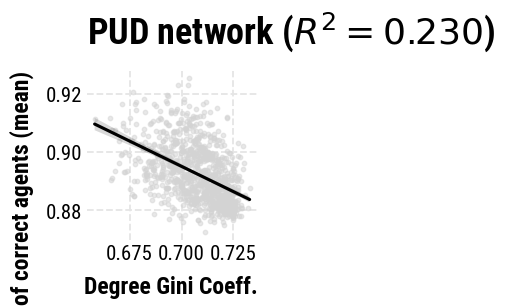

In [60]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    filename="pud_regression_plot"
)

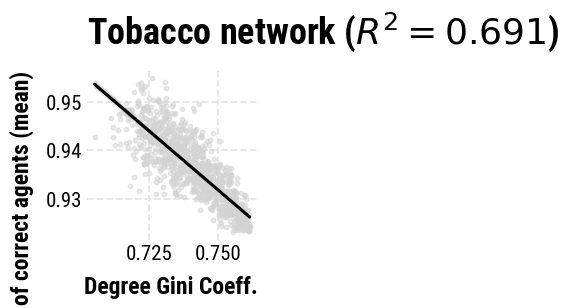

In [61]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    filename="tobacco_regression_plot"
)

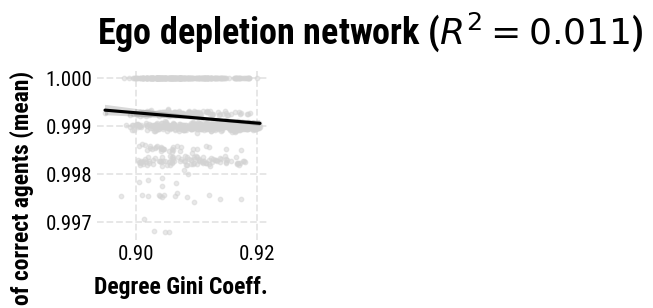

In [62]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    filename="ego_regression_plot"
)

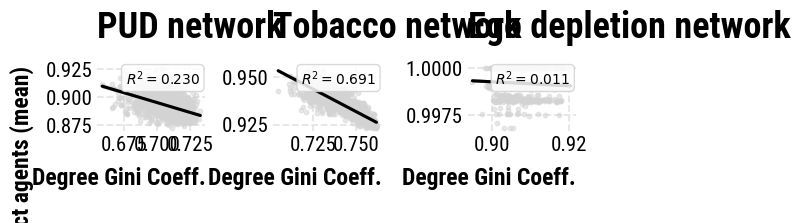

In [63]:
plot_multiple_linear_regressions(
    dfs=[df_pud, df_tobacco, df_ego],
    titles=["PUD network", "Tobacco network", "Ego depletion network"],
    filename="hard_problems_regression_grid",
)

## Moderate problems ($\varepsilon = 0.01$)

### Load csv and create dataframes

⚠️ Note: Depending on the details of the simulation study, you might have to include `uncertainty` and/or `n_experiments` as predictors.

In [64]:
df_summary = load_summary(slug="moderate")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient",
] # "uncertainty", "n_experiments"]

In [65]:
print(df_pud["n_experiments"].value_counts())
uncertainty_values = df_pud["uncertainty"].values
print(f"Problem Easiness.\n\t Min: {min(uncertainty_values):.5f}\n\t Max: {max(uncertainty_values):.5f}")

n_experiments
1000    1000
Name: count, dtype: int64
Problem Easiness.
	 Min: 0.01000
	 Max: 0.01000


### Linear regressions: Short summaries

In [66]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.257 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.485733,0.307599,Medium,0.000
Clustering Coeff.,0.082572,0.008889,Negligible,0.003


🔍 TOBACCO — Linear Regression — Short Summary
R² = 0.697 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.835041,2.298331,Large,0.0000
Clustering Coeff.,0.016180,0.000863,Negligible,0.3539


🔍 EGO — Linear Regression — Short Summary
R² = 0.035 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.188534,0.035911,Small,0.0000
Clustering Coeff.,0.004229,0.000018,Negligible,0.8933


### Linear regressions: Full overview

In [67]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.257 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.485733,0.307599,Medium,0.000
Clustering Coeff.,0.082572,0.008889,Negligible,0.003


------------------------------------------------------------
Descriptive Statistics
------------------------------------------------------------
- The length of the data is: 1,000


,Mean,Std,Min,Max
degree_gini_coefficient,0.70746,0.013400,0.658750,0.73500
approx_average_clustering_coefficient,0.16561,0.005038,0.136751,0.18688


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


...

,Mean,Std,Min,Max
degree_gini_coefficient,0.909898,0.005923,0.897349,0.920455
approx_average_clustering_coefficient,0.592367,0.003167,0.566208,0.600235


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


,,correlation,interpretation
variable 1,variable 2,,
Degree Gini Coeff.,Clustering Coeff.,0.15933,weak


,VIF,VIF interpretation
variable,,
Degree Gini Coeff.,1.026047,minimal multicollinearity
Clustering Coeff.,1.026047,minimal multicollinearity


------------------------------------------------------------
Full Summary
------------------------------------------------------------
                                  OLS Regression Results                                  
Dep. Variable:     Share of correct agents (mean)   R-squared:                       0.035
Model:                                        OLS   Adj. R-squared:                  0.033
Method:                             Least Squares   F-statistic:                     18.25
Date:                            Tue, 15 Sep 2026   Prob (F-statistic):           1.65e-08
Time:                                    20:29:11   Log-Likelihood:                 5949.7
No. Observations:                            1000   AIC:                        -1.189e+04
Df Residuals:                                 997   BIC:                        -1.188e+04
Df Model:                                       2                                         
Covariance Type:                        nonrob

### Combined LaTeX table (PUD / Tobacco / Ego)

In [68]:
combined_stats = {}
for df in [df_pud, df_tobacco, df_ego]:
    reg_stats = linear_regression(
        df,
        predictors=predictors,
        print_results=False,
        return_stats=True,
    )
    combined_stats[reg_stats["column_label"]] = reg_stats

combined_latex = regression_stats_to_latex(
    combined_stats,
    column_labels={"pud": "PUD", "tobacco": "Tobacco", "ego": "Ego depletion"},
)
print(combined_latex)

\begin{table}[!htbp]
    \centering
    \begin{threeparttable}
    \begin{tabular}{lccc}
    \toprule
     & \multicolumn{3}{c}{\textit{Dependent variable: Share of correct agents (mean)}} \\
    \midrule
     & PUD & Tobacco & Ego depletion \\
    \midrule
    Degree Gini Coeff. & $-0.486^{***}$ & $-0.835^{***}$ & $-0.189^{***}$ \\
    & (0.028) & (0.017) & (0.032) \\
    Clustering Coeff. & $0.083^{**}$ & $0.016$ & $0.004$ \\
    & (0.028) & (0.017) & (0.032) \\
    \midrule
    Observations & 1,000 & 1,000 & 1,000 \\
    $R^{2}$ & 0.257 & 0.697 & 0.035 \\
    Adjusted $R^{2}$ & 0.255 & 0.696 & 0.033 \\
    Residual Std. Error & 0.863 & 0.551 & 0.983 \\
    & (df = 997) & (df = 997) & (df = 997) \\
    F Statistic & $172.367^{***}$ & $1145.783^{***}$ & $18.246^{***}$ \\
    & (df = 2; 997) & (df = 2; 997) & (df = 2; 997) \\
    \bottomrule
    \end{tabular}
    \begin{tablenotes}
    \small
    \item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001
    \end{tablenotes}
    \end{

### Plots

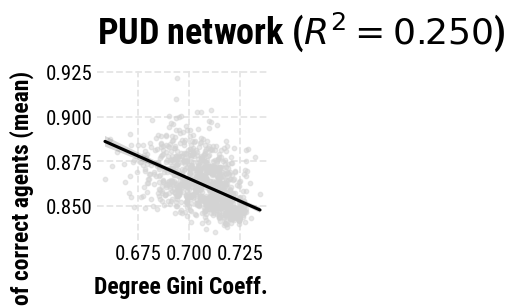

In [69]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    filename="pud_regression_plot"
)

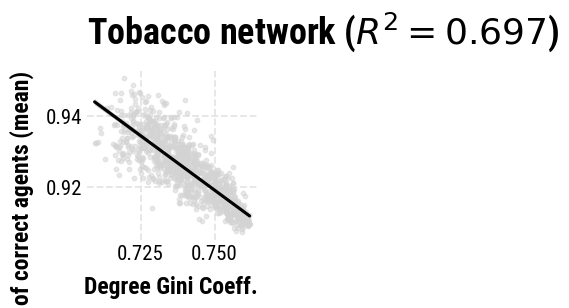

In [70]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    filename="tobacco_regression_plot"
)

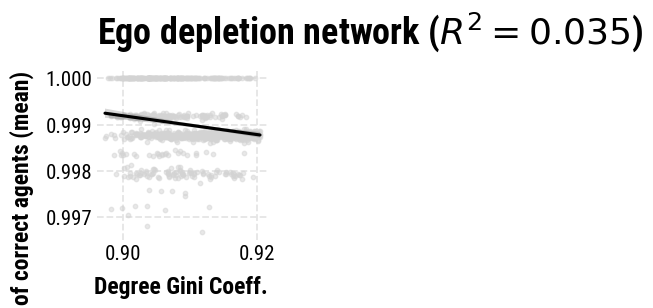

In [71]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    filename="ego_regression_plot"
)

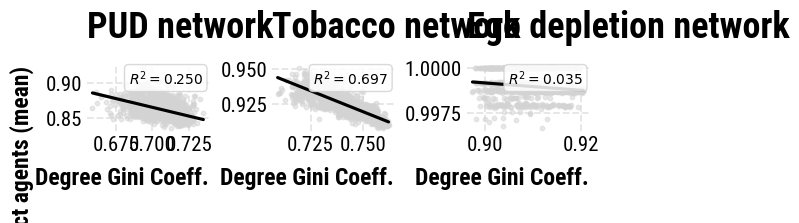

In [72]:
plot_multiple_linear_regressions(
    dfs=[df_pud, df_tobacco, df_ego],
    titles=["PUD network", "Tobacco network", "Ego depletion network"],
    filename="hard_problems_regression_grid",
)

## Hard problems ($\varepsilon = 0.001$), following the literature

### Load csv and create dataframes

⚠️ Note: Depending on the details of the simulation study, you might have to include `uncertainty` and/or `n_experiments` as predictors.

In [46]:
df_summary = load_summary(slug="hard")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient",
] # "uncertainty", "n_experiments"]

In [47]:
print(df_pud["n_experiments"].value_counts())
uncertainty_values = df_pud["uncertainty"].values
print(f"Problem Easiness.\n\t Min: {min(uncertainty_values):.5f}\n\t Max: {max(uncertainty_values):.5f}")

n_experiments
1000    1000
Name: count, dtype: int64
Problem Easiness.
	 Min: 0.00100
	 Max: 0.00100


### Linear regressions: Short summaries

In [48]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.179 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.425070,0.214055,Medium,0.0000
Clustering Coeff.,-0.009038,0.000097,Negligible,0.7562


🔍 TOBACCO — Linear Regression — Short Summary
R² = 0.685 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.828238,2.160309,Large,0.0000
Clustering Coeff.,0.011327,0.000404,Negligible,0.5258


🔍 EGO — Linear Regression — Short Summary
R² = 0.077 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.282339,0.083573,Small,0.000
Clustering Coeff.,0.043598,0.001993,Negligible,0.159


### Linear regressions: Full overview

In [49]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.179 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.425070,0.214055,Medium,0.0000
Clustering Coeff.,-0.009038,0.000097,Negligible,0.7562


------------------------------------------------------------
Descriptive Statistics
------------------------------------------------------------
- The length of the data is: 1,000


,Mean,Std,Min,Max
degree_gini_coefficient,0.707403,0.013809,0.660556,0.735278
approx_average_clustering_coefficient,0.165503,0.005049,0.138200,0.188163


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


...

,Mean,Std,Min,Max
degree_gini_coefficient,0.910011,0.006073,0.896546,0.920430
approx_average_clustering_coefficient,0.592570,0.002867,0.569674,0.599819


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


,,correlation,interpretation
variable 1,variable 2,,
Degree Gini Coeff.,Clustering Coeff.,0.180315,weak


,VIF,VIF interpretation
variable,,
Degree Gini Coeff.,1.033606,minimal multicollinearity
Clustering Coeff.,1.033606,minimal multicollinearity


------------------------------------------------------------
Full Summary
------------------------------------------------------------
                                  OLS Regression Results                                  
Dep. Variable:     Share of correct agents (mean)   R-squared:                       0.077
Model:                                        OLS   Adj. R-squared:                  0.075
Method:                             Least Squares   F-statistic:                     41.69
Date:                            Tue, 15 Sep 2026   Prob (F-statistic):           4.09e-18
Time:                                    20:27:57   Log-Likelihood:                 5598.5
No. Observations:                            1000   AIC:                        -1.119e+04
Df Residuals:                                 997   BIC:                        -1.118e+04
Df Model:                                       2                                         
Covariance Type:                        nonrob

### Combined LaTeX table (PUD / Tobacco / Ego)

In [50]:
combined_stats = {}
for df in [df_pud, df_tobacco, df_ego]:
    reg_stats = linear_regression(
        df,
        predictors=predictors,
        print_results=False,
        return_stats=True,
    )
    combined_stats[reg_stats["column_label"]] = reg_stats

combined_latex = regression_stats_to_latex(
    combined_stats,
    column_labels={"pud": "PUD", "tobacco": "Tobacco", "ego": "Ego depletion"},
)
print(combined_latex)

\begin{table}[!htbp]
    \centering
    \begin{threeparttable}
    \begin{tabular}{lccc}
    \toprule
     & \multicolumn{3}{c}{\textit{Dependent variable: Share of correct agents (mean)}} \\
    \midrule
     & PUD & Tobacco & Ego depletion \\
    \midrule
    Degree Gini Coeff. & $-0.425^{***}$ & $-0.828^{***}$ & $-0.282^{***}$ \\
    & (0.029) & (0.018) & (0.031) \\
    Clustering Coeff. & $-0.009$ & $0.011$ & $0.044$ \\
    & (0.029) & (0.018) & (0.031) \\
    \midrule
    Observations & 1,000 & 1,000 & 1,000 \\
    $R^{2}$ & 0.179 & 0.685 & 0.077 \\
    Adjusted $R^{2}$ & 0.178 & 0.684 & 0.075 \\
    Residual Std. Error & 0.907 & 0.562 & 0.962 \\
    & (df = 997) & (df = 997) & (df = 997) \\
    F Statistic & $109.043^{***}$ & $1081.913^{***}$ & $41.690^{***}$ \\
    & (df = 2; 997) & (df = 2; 997) & (df = 2; 997) \\
    \bottomrule
    \end{tabular}
    \begin{tablenotes}
    \small
    \item {} $^{*}$p$<$0.05; $^{**}$p$<$0.01; $^{***}$p$<$0.001
    \end{tablenotes}
    \end{thre

### Plots

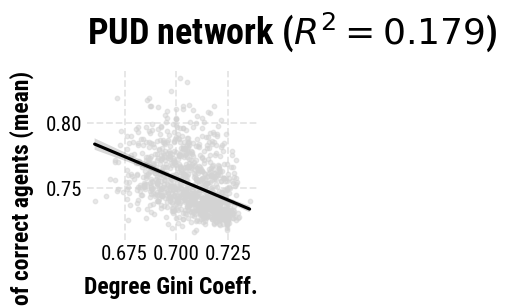

In [51]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    filename="pud_regression_plot"
)

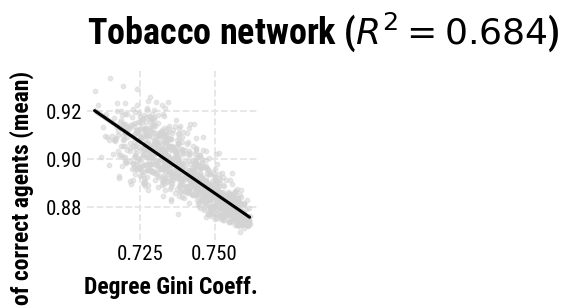

In [52]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    filename="tobacco_regression_plot"
)

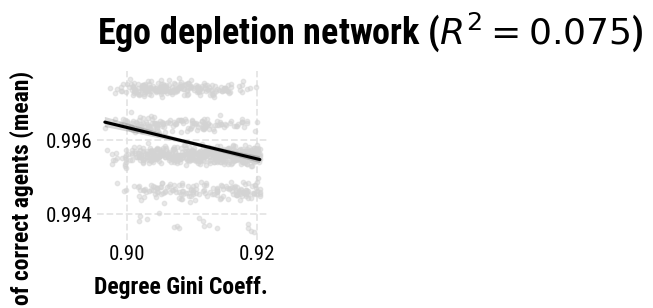

In [53]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    filename="ego_regression_plot"
)

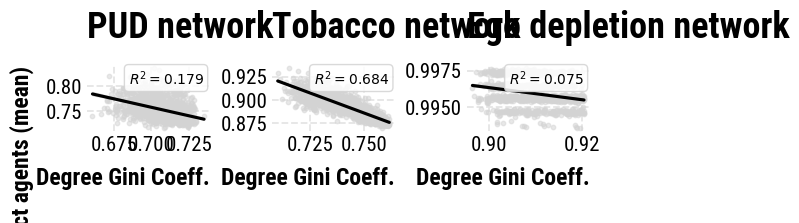

In [54]:
plot_multiple_linear_regressions(
    dfs=[df_pud, df_tobacco, df_ego],
    titles=["PUD network", "Tobacco network", "Ego depletion network"],
    filename="hard_problems_regression_grid",
)

## Super hard problems ($\varepsilon = 0.0001$)

⚠️ Note: `uncertainty` is held **fixed** at `0.0001` in this option, so it is not a predictor here — unlike Option 3, which draws it per setting. A constant column would contribute nothing to the fit and make `n_experiments` look collinear with the intercept.

The csv is produced by `2d. GColab Simulations Equality - Aggregation.ipynb`; copy it into `results/` before running this section.

### Load csv and create dataframes

⚠️ Note: Depending on the details of the simulation study, you might have to include `uncertainty` and/or `n_experiments` as predictors.

In [73]:
df_summary = load_summary(slug="super_hard")
df_pud = df_summary[df_summary["network"] == "pud"]
df_tobacco = df_summary[df_summary["network"] == "tobacco"]
df_ego = df_summary[df_summary["network"] == "ego"]
predictors = [
    "degree_gini_coefficient", 
    "approx_average_clustering_coefficient"]

In [74]:
print(df_pud["n_experiments"].value_counts())
uncertainty_values = df_pud["uncertainty"].values
print(f"Problem Easiness.\n\t Min: {min(uncertainty_values):.5f}\n\t Max: {max(uncertainty_values):.5f}")

n_experiments
1000    1000
Name: count, dtype: int64
Problem Easiness.
	 Min: 0.00010
	 Max: 0.00010


### Linear regressions: Short summaries

In [75]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=False,
)
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=False,
)
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=False,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.213 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.454909,0.255841,Medium,0.0000
Clustering Coeff.,0.034651,0.001484,Negligible,0.2241


🔍 TOBACCO — Linear Regression — Short Summary
R² = 0.693 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.833667,2.249281,Large,0.0000
Clustering Coeff.,0.021515,0.001498,Negligible,0.2219


🔍 EGO — Linear Regression — Short Summary
R² = 0.673 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.821687,2.021303,Large,0.0000
Clustering Coeff.,0.009243,0.000256,Negligible,0.6137


### Linear regressions: Full overview

In [76]:
linear_regression(
    df_pud, 
    predictors=predictors, 
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_tobacco, 
    predictors=predictors,
    print_full_summary=True,
)
print("\n\n")
linear_regression(
    df_ego, 
    predictors=predictors, 
    print_full_summary=True,
)

🔍 PUD — Linear Regression — Short Summary
R² = 0.213 (coefficient of determination)
✅ VIF and Pearson correlations were minimal, insignificant and/or weak


,Normalized Coef,f²,f² Interpretation,p-value
Degree Gini Coeff.,-0.454909,0.255841,Medium,0.0000
Clustering Coeff.,0.034651,0.001484,Negligible,0.2241


------------------------------------------------------------
Descriptive Statistics
------------------------------------------------------------
- The length of the data is: 1,000


,Mean,Std,Min,Max
degree_gini_coefficient,0.707409,0.013358,0.665417,0.735972
approx_average_clustering_coefficient,0.165651,0.005029,0.142118,0.184683


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


...

,Mean,Std,Min,Max
degree_gini_coefficient,0.909629,0.005899,0.895798,0.920430
approx_average_clustering_coefficient,0.592546,0.002707,0.570403,0.599542


------------------------------------------------------------
Collinearity results
------------------------------------------------------------


,,correlation,interpretation
variable 1,variable 2,,
Degree Gini Coeff.,Clustering Coeff.,0.145493,weak


,VIF,VIF interpretation
variable,,
Degree Gini Coeff.,1.021626,minimal multicollinearity
Clustering Coeff.,1.021626,minimal multicollinearity


------------------------------------------------------------
Full Summary
------------------------------------------------------------
                                  OLS Regression Results                                  
Dep. Variable:     Share of correct agents (mean)   R-squared:                       0.673
Model:                                        OLS   Adj. R-squared:                  0.672
Method:                             Least Squares   F-statistic:                     1026.
Date:                            Tue, 15 Sep 2026   Prob (F-statistic):          9.39e-243
Time:                                    20:29:13   Log-Likelihood:                 3835.5
No. Observations:                            1000   AIC:                            -7665.
Df Residuals:                                 997   BIC:                            -7650.
Df Model:                                       2                                         
Covariance Type:                        nonrob

### Plots

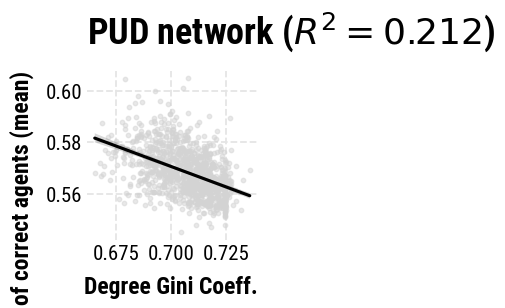

In [77]:
plot_linear_regression(
    df_pud, 
    x="degree_gini_coefficient", 
    y="mean_share_of_correct_agents_at_convergence", 
    title="PUD network",
    # filename="pud_regression_plot"
)

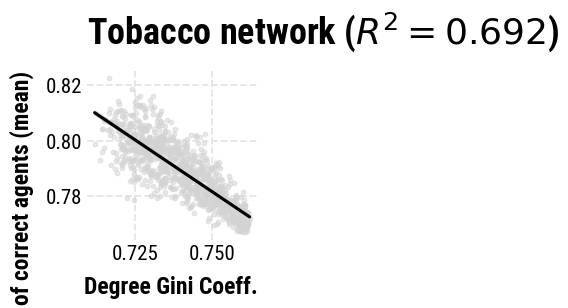

In [78]:
plot_linear_regression(
    df_tobacco,
    title="Tobacco network",
    # filename="tobacco_regression_plot"
)

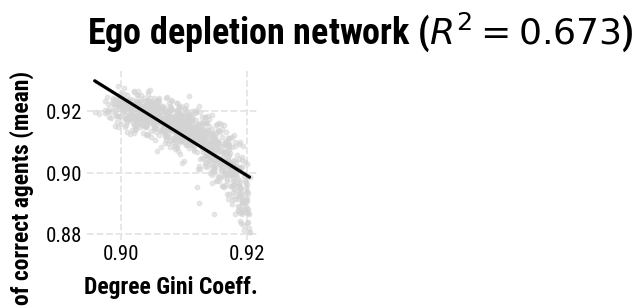

In [79]:
plot_linear_regression(
    df_ego,
    title="Ego depletion network",
    # filename="ego_regression_plot"
)

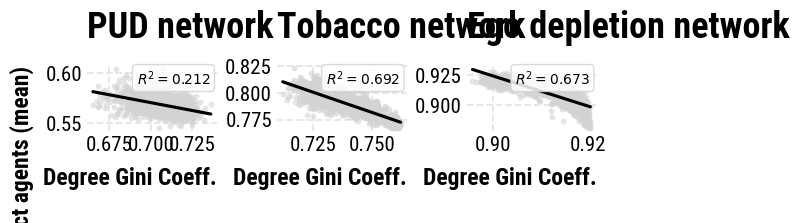

In [80]:
plot_multiple_linear_regressions(
    dfs=[df_pud, df_tobacco, df_ego],
    titles=["PUD network", "Tobacco network", "Ego depletion network"],
    filename="super_hard_problems_regression_grid",
)

### Combined LaTeX table (all networks × difficulties, horizontal)

In [91]:
difficulty_labels = {"easy": "Easy", "moderate": "Moderate", "hard": "Hard", "super_hard": "Super hard"}
network_labels = {"pud": "PUD", "tobacco": "Tobacco", "ego": "Ego depletion"}

summaries_by_difficulty = {difficulty: load_summary(slug=difficulty) for difficulty in difficulty_labels}

horizontal_stats = {}
horizontal_row_info = {}
for network in network_labels:
    for difficulty, df_summary in summaries_by_difficulty.items():
        df_network = df_summary[df_summary["network"] == network]
        if df_network.empty:
            continue
        row_key = f"{network}_{difficulty}"
        reg_stats = linear_regression(
            df_network,
            predictors=predictors,
            print_results=False,
            return_stats=True,
        )
        horizontal_stats[row_key] = reg_stats
        horizontal_row_info[row_key] = (network_labels[network], difficulty_labels[difficulty])

horizontal_latex = regression_stats_to_latex_horizontal(
    horizontal_stats,
    row_info=horizontal_row_info,
    caption="Degree inequality and reliability in the new local equality study",
    label="tab:combined-inequality-horizontal",
)
print(horizontal_latex)

\begin{table}[!htbp]
    \centering
    \caption{Degree inequality and reliability in the new local equality study}
    \label{tab:combined-inequality-horizontal}
    \begin{threeparttable}
    \begin{tabular}{llcccccc}
    \toprule
    Network & Difficulty & Degree Gini Coeff. & Clustering Coeff. & Obs. & $R^{2}$ & $R^{2}$ (adj.) & F Statistic \\
    \midrule
    \multirow{4}{*}{PUD} & Easy & $-0.469^{***}$ (0.028) & $0.079^{**}$ (0.028) & 1,000 & 0.236 & 0.235 & $154.154^{***}$ \\
     & Moderate & $-0.486^{***}$ (0.028) & $0.083^{**}$ (0.028) & 1,000 & 0.257 & 0.255 & $172.367^{***}$ \\
     & Hard & $-0.425^{***}$ (0.029) & $-0.009$ (0.029) & 1,000 & 0.179 & 0.178 & $109.043^{***}$ \\
     & Super hard & $-0.455^{***}$ (0.028) & $0.035$ (0.028) & 1,000 & 0.213 & 0.212 & $135.217^{***}$ \\
    \multirow{4}{*}{Tobacco} & Easy & $-0.830^{***}$ (0.018) & $-0.030$ (0.018) & 1,000 & 0.692 & 0.692 & $1121.931^{***}$ \\
     & Moderate & $-0.835^{***}$ (0.017) & $0.016$ (0.017) & 1,000 & 0

## Combined analysis: new local equality study

This section uses **only `data/equality_study/<condition>/full/`**, extracted from `data/equality_study.zip`. The original Option 1–3 regressions above retain their historical inputs and specifications. No historical rows are mixed into this combined analysis.

The new study has four **fixed** easiness levels: easy ($\varepsilon=0.1$), moderate ($0.01$), hard ($0.001$), and super hard ($0.0001$). There is no varying-easiness condition in these inputs. `RUN_TAG` selects `full` or `smoke`; the loader reports exactly what is available. Existing `variant_summary.csv` files are read directly; where a summary is absent, the downloaded variant shards are aggregated with the project's `summarise_arm` function.

**The current download is incomplete.** Easy, moderate, and hard each contain 1,000 variants for each network. Super hard contains only 864 Ego variants; PUD and Tobacco are absent. The archive's `data/___All_Errors.txt` lists download failures. Missing network–condition groups are omitted from the fit and plot, and partial groups are labeled in the table. The coverage report below updates when more files are added.

One OLS model fits a separate intercept, Gini slope, and clustering slope for every available network–condition group:

$$
100\,\bar y_{vc} = \alpha_c + \beta_c\frac{G_{vc}-\bar G_c}{0.01}
+ \gamma_c\frac{K_{vc}-\bar K_c}{0.01} + u_{vc}.
$$

Easiness is fixed within each condition, so no within-condition easiness slope is fitted. The table reports the **percentage-point change in reliability for a 0.01 increase in degree Gini**, controlling for clustering. A negative slope supports the equality effect. Each row is a variant mean, currently based on 1,000 simulation runs.

Uncertainty is clustered by **network, method, and variation seed**. Variant indices restart in each condition and do not identify the same graph across conditions; the new conditions use different master seeds. The loader checks graph identity only for genuinely repeated variation seeds. In the current download all 9,864 variant clusters are distinct.

The overall row averages Gini slopes with equal weights across **conditions complete for all three networks**: currently easy, moderate, and hard (nine slopes). Super-hard Ego is reported separately but excluded from that balanced average. The overall row therefore does not summarize all four difficulties. Pointwise confidence intervals and a joint equal-slopes test use the fitted covariance; there is no common-slope constraint or hierarchical shrinkage.

**Significance and multiple testing.** Stars beside effects use Holm-adjusted p-values: \* p < 0.05, \*\* p < 0.01, \*\*\* p < 0.001. The table reports significance only through stars. [Holm correction](https://stat.ethz.ch/R-manual/R-devel/library/stats/html/p.adjust.html) is applied across the ten available group slopes, the balanced-average contrast, and the joint equal-slopes test (12 tests for the current download). The notes identify the correction and its test family. Raw and adjusted p-values remain available in `pooled_effects["p-value"]` and `pooled_effects["p (Holm)"]`.

The 95% confidence intervals in the table and plots remain **pointwise**, rather than simultaneous intervals. The stars test each reported effect against zero; they do not establish which conditions differ from one another. The joint equal-slopes test assesses whether all group slopes are equal. Specific pairwise differences would require contrasts from this model and an explicitly defined correction family.


In [83]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from model.equality_study import completed_variants, summarise_arm

pooled_root = Path(globals().get('REPO_ROOT', Path.cwd())).resolve()
while not (pooled_root / '3. Results Data Analysis.ipynb').is_file():
    if pooled_root == pooled_root.parent:
        raise FileNotFoundError('Start the kernel in the project folder, or run the setup cells first.')
    pooled_root = pooled_root.parent

POOLED_STUDY_ROOT = pooled_root / 'results' / 'equality_study'
run_tag = globals().get('RUN_TAG', 'full')
if not POOLED_STUDY_ROOT.is_dir():
    raise FileNotFoundError(f'Extract data/equality_study.zip into {pooled_root / "data"} before running this section.')
pooled_conditions = {
    'easy': ('easy', 'Easy'),
    'moderate': ('moderate', 'Moderate'),
    'hard': ('hard', 'Hard'),
    'super_hard': ('super_hard', 'Super hard'),
}
pooled_expected_easiness = {'easy': 0.1, 'moderate': 0.01, 'hard': 0.001, 'super_hard': 0.0001}
pooled_networks = {'pud': 'PUD', 'tobacco': 'Tobacco', 'ego': 'Ego depletion'}
parts, coverage_rows = [], []
pooled_sources = {}
for condition, (slug, label) in pooled_conditions.items():
    directory = POOLED_STUDY_ROOT / slug / run_tag
    config_path = directory / 'equality_study_config.json'
    config = json.loads(config_path.read_text()) if config_path.is_file() else {}
    cost_path = directory / 'cost_all_arms.csv'
    cost = pd.read_csv(cost_path) if cost_path.is_file() else pd.DataFrame()
    summary_path = directory / 'variant_summary.csv'
    if summary_path.is_file():
        part = pd.read_csv(summary_path)
        source = str(summary_path)
    else:
        arm_parts = []
        for network in pooled_networks:
            arm_path = directory / f'{network}_equalize'
            if completed_variants(arm_path):
                print(f'Aggregating downloaded shards: {arm_path}', flush=True)
                arm_parts.append(summarise_arm(arm_path))
        part = pd.concat(arm_parts, ignore_index=True) if arm_parts else pd.DataFrame()
        source = f'{directory} (aggregated downloaded shards)'
    if not part.empty:
        part['condition'] = condition
        parts.append(part)
        pooled_sources[condition] = source
    for network in pooled_networks:
        available = int(part['network'].eq(network).sum()) if not part.empty else 0
        target = config.get('n_variants')
        # A downloaded cost log can establish the source's completed variants
        # even when the archive omitted that condition's config and summary.
        if target is None and not cost.empty:
            target = int(cost.loc[
                cost['network'].eq(network) & cost['method'].eq('equalize'),
                'variant_index',
            ].nunique()) or None
        status = (
            'missing' if available == 0 else
            'complete' if target is not None and available >= target else
            'partial' if target is not None else 'target unknown'
        )
        coverage_rows.append({
            'network': network, 'condition': condition,
            'variants_loaded': available, 'variants_expected': target,
            'shards_downloaded': len(completed_variants(directory / f'{network}_equalize')),
            'status': status,
        })
if not parts:
    raise FileNotFoundError(f'No study summaries or variant shards found for {run_tag!r} in {POOLED_STUDY_ROOT}.')
pooled_data = pd.concat(parts, ignore_index=True)
pooled_coverage = pd.DataFrame(coverage_rows)
pooled_coverage['variants_expected'] = pooled_coverage['variants_expected'].astype('Int64')

numeric_columns = [
    'variant_index', 'variation_seed', 'n_runs', 'n_experiments', 'uncertainty',
    'degree_gini_coefficient', 'approx_average_clustering_coefficient',
    'mean_share_of_correct_agents_at_convergence',
]
required = ['network', 'method', *numeric_columns]
if pooled_data[required].isna().any().any():
    raise ValueError('Missing combined-model inputs; no rows have been silently dropped.')
if not np.isfinite(pooled_data[numeric_columns].to_numpy(dtype=float)).all():
    raise ValueError('Non-finite combined-model inputs.')
if not set(pooled_data['network']).issubset(pooled_networks) or set(pooled_data['method']) != {'equalize'}:
    raise ValueError('This specification expects PUD, Tobacco, and Ego equalize variants only.')
if pooled_data.duplicated(['condition', 'network', 'method', 'variant_index']).any():
    raise ValueError('Duplicate variant rows within a condition.')
if not pooled_data['mean_share_of_correct_agents_at_convergence'].between(0, 1).all():
    raise ValueError('Reliability must be a proportion between zero and one.')
if (pooled_data['n_runs'] <= 0).any() or pooled_data['n_experiments'].nunique() != 1:
    raise ValueError('Invalid run counts or varying experiment counts; inspect the study configuration.')
for condition, subset in pooled_data.groupby('condition'):
    if not np.allclose(subset['uncertainty'], pooled_expected_easiness[condition], rtol=0, atol=1e-12):
        raise ValueError(f'Unexpected easiness values in {condition}.')

# Index 0 in two conditions can be two different graphs: compare actual seeds.
identity = ['network', 'method', 'variation_seed']
structural = ['degree_gini_coefficient', 'approx_average_clustering_coefficient']
if (pooled_data.groupby(identity)[structural].nunique() > 1).any().any():
    raise ValueError('A repeated variation seed identifies inconsistent structural covariates.')
cluster_keys = pd.MultiIndex.from_frame(pooled_data[identity])
pooled_data['cluster_id'] = pd.factorize(cluster_keys)[0]
pooled_data['reliability_pp'] = 100 * pooled_data['mean_share_of_correct_agents_at_convergence']
pooled_data['group'] = pooled_data['network'] + '__' + pooled_data['condition']
pooled_groups = [f'{network}__{condition}' for network in pooled_networks for condition in pooled_conditions
                 if f'{network}__{condition}' in set(pooled_data['group'])]
pooled_complete_conditions = [condition for condition in pooled_conditions
    if pooled_coverage.loc[pooled_coverage['condition'].eq(condition), 'status'].eq('complete').all()]
pooled_balanced_groups = [group for group in pooled_groups if group.split('__')[1] in pooled_complete_conditions]
counts = pooled_data.groupby(['network', 'condition']).size().unstack(fill_value=0).reindex(
    index=pooled_networks, columns=pooled_conditions, fill_value=0,
).fillna(0).astype(int)
print(f'New local study: {POOLED_STUDY_ROOT} / {run_tag}')
print(counts.rename(index=pooled_networks, columns={k: v[1] for k, v in pooled_conditions.items()}).to_string())
display(pooled_coverage.rename(columns={
    'network': 'Network', 'condition': 'Condition', 'variants_loaded': 'Variants loaded',
    'variants_expected': 'Expected variants', 'shards_downloaded': 'Downloaded shards', 'status': 'Coverage',
}))
print(f'{len(pooled_data):,} variant means; {pooled_data.cluster_id.nunique():,} variant clusters; '
      f'{int(pooled_data.n_runs.sum()):,} underlying simulation runs.')
print(f'Replicates per mean: {pooled_data.n_runs.min():g}–{pooled_data.n_runs.max():g}; unweighted OLS.')
for row in pooled_coverage.loc[~pooled_coverage['status'].eq('complete')].itertuples():
    print(f'INCOMPLETE DOWNLOAD: {row.condition}/{row.network}: '
          f'{row.variants_loaded:,} of {row.variants_expected} variants ({row.status}).')
download_errors = pooled_root / 'data' / '___All_Errors.txt'
if download_errors.is_file():
    print(f'Archive download-error log: {download_errors}')
for condition, source in pooled_sources.items():
    print(f'{pooled_conditions[condition][1]}: {source}')

New local study: /Users/heinduijf/GitHub/e_network_inequality/results/equality_study / full
condition      Easy  Moderate  Hard  Super hard
network                                        
PUD            1000      1000  1000        1000
Tobacco        1000      1000  1000        1000
Ego depletion  1000      1000  1000        1000


,Network,Condition,Variants loaded,Expected variants,Downloaded shards,Coverage
0,pud,easy,1000,1000,1000,complete
1,tobacco,easy,1000,1000,1000,complete
2,ego,easy,1000,1000,1000,complete
3,pud,moderate,1000,1000,1000,complete
4,tobacco,moderate,1000,1000,1000,complete
5,ego,moderate,1000,1000,1000,complete
6,pud,hard,1000,1000,1000,complete
7,tobacco,hard,1000,1000,1000,complete
8,ego,hard,1000,1000,1000,complete
9,pud,super_hard,1000,1000,1000,complete


12,000 variant means; 12,000 variant clusters; 12,000,000 underlying simulation runs.
Replicates per mean: 1000–1000; unweighted OLS.
Easy: /Users/heinduijf/GitHub/e_network_inequality/results/equality_study/easy/full/variant_summary.csv
Moderate: /Users/heinduijf/GitHub/e_network_inequality/results/equality_study/moderate/full/variant_summary.csv
Hard: /Users/heinduijf/GitHub/e_network_inequality/results/equality_study/hard/full/variant_summary.csv
Super hard: /Users/heinduijf/GitHub/e_network_inequality/results/equality_study/super_hard/full/variant_summary.csv


In [84]:
# One design matrix: intercept, Gini, and clustering for each available group.
pooled_X = pd.DataFrame(index=pooled_data.index)
pooled_gini_terms = {}
for group in pooled_groups:
    mask = pooled_data['group'].eq(group)
    subset = pooled_data.loc[mask]
    pooled_X[f'{group}__intercept'] = mask.astype(float)
    for short, source, step in [
        ('gini', 'degree_gini_coefficient', 0.01),
        ('clustering', 'approx_average_clustering_coefficient', 0.01),
    ]:
        term = f'{group}__{short}'
        pooled_X[term] = 0.0
        pooled_X.loc[mask, term] = (
            subset[source] - subset[source].mean()
        ) / step
        if short == 'gini':
            pooled_gini_terms[group] = term
    if subset['uncertainty'].nunique() != 1:
        raise ValueError(f'Easiness unexpectedly varies within {group}.')

if np.linalg.matrix_rank(pooled_X.to_numpy()) != pooled_X.shape[1]:
    raise ValueError('The combined design matrix is rank deficient; inspect constant or collinear predictors.')
pooled_model = sm.OLS(pooled_data['reliability_pp'], pooled_X, missing='raise').fit(
    cov_type='cluster',
    cov_kwds={'groups': pooled_data['cluster_id'], 'use_correction': True, 'df_correction': True},
    use_t=True,
)
within_y = pooled_data['reliability_pp'] - pooled_data.groupby('group')['reliability_pp'].transform('mean')
pooled_within_r2 = 1 - np.sum(pooled_model.resid ** 2) / np.sum(within_y ** 2)
print(f'One joint OLS fit: {int(pooled_model.nobs):,} rows, {pooled_X.shape[1]} coefficients, '
      f'{pooled_data.cluster_id.nunique():,} variant clusters.')
print(f'R² beyond separate network–condition intercepts: {pooled_within_r2:.3f}')
# The full coefficient listing remains available as pooled_model.summary().

One joint OLS fit: 12,000 rows, 36 coefficients, 12,000 variant clusters.
R² beyond separate network–condition intercepts: 0.387


In [85]:
from statsmodels.stats.multitest import multipletests

def contrast_row(label, network, condition, n_rows, weights):
    contrast = np.zeros(len(pooled_model.params))
    for term, weight in weights.items():
        contrast[pooled_model.params.index.get_loc(term)] = weight
    test = pooled_model.t_test(contrast)
    lo, hi = np.asarray(test.conf_int(alpha=0.05)).reshape(-1)
    scalar = lambda value: float(np.asarray(value).item())
    return {
        'Estimand': label, 'Network': network, 'Condition': condition, 'Rows': n_rows,
        'Effect (pp)': scalar(test.effect), 'SE (pp)': scalar(test.sd),
        'CI low (pp)': lo, 'CI high (pp)': hi, 'p-value': scalar(test.pvalue),
    }

effect_rows = []
for group in pooled_groups:
    network, condition = group.split('__')
    group_status = pooled_coverage.loc[
        pooled_coverage['network'].eq(network) & pooled_coverage['condition'].eq(condition), 'status',
    ].iloc[0]
    condition_label = pooled_conditions[condition][1] + (' (partial)' if group_status != 'complete' else '')
    effect_rows.append(contrast_row(
        group, pooled_networks[network], condition_label,
        int(pooled_data['group'].eq(group).sum()),
        {pooled_gini_terms[group]: 1.0},
    ))
if pooled_balanced_groups:
    effect_rows.append(contrast_row(
        'equal_cell_average', 'All three', 'Balanced average',
        int(pooled_data['group'].isin(pooled_balanced_groups).sum()),
        {pooled_gini_terms[group]: 1 / len(pooled_balanced_groups) for group in pooled_balanced_groups},
    ))
pooled_effects = pd.DataFrame(effect_rows).set_index('Estimand')

# Test a common Gini slope across all available groups.
restrictions = np.zeros((len(pooled_groups) - 1, len(pooled_model.params)))
reference = pooled_model.params.index.get_loc(pooled_gini_terms[pooled_groups[0]])
for i, group in enumerate(pooled_groups[1:]):
    restrictions[i, reference] = -1
    restrictions[i, pooled_model.params.index.get_loc(pooled_gini_terms[group])] = 1
pooled_heterogeneity_test = pooled_model.f_test(restrictions)
heterogeneity_p = float(np.asarray(pooled_heterogeneity_test.pvalue).item())

# Treat every reported Gini test here as one family, including the average and omnibus test.
pooled_test_pvalues = pd.concat([
    pooled_effects['p-value'], pd.Series({'equal_slopes': heterogeneity_p}),
])
pooled_adjusted_p = pd.Series(
    multipletests(pooled_test_pvalues, method='holm')[1], index=pooled_test_pvalues.index,
)
pooled_effects['p (Holm)'] = pooled_adjusted_p.reindex(pooled_effects.index)


def significance_stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''


pooled_effects['Significance'] = pooled_effects['p (Holm)'].map(significance_stars)
pooled_correction_note = (
    f'Holm correction is applied across {len(pooled_test_pvalues)} tests '
    f'({len(pooled_effects)} table contrasts plus the equal-slopes test). '
)

# The average's uncertainty uses the full covariance, including cross-condition covariance.
pooled_summary_table = pooled_effects[['Network', 'Condition', 'Rows']].copy()
pooled_summary_table['Effect (pp)'] = pooled_effects['Effect (pp)'].map(lambda x: f'{x:.3f}') + pooled_effects['Significance']
pooled_summary_table['95% CI (pp)'] = pooled_effects.apply(
    lambda row: f'[{row["CI low (pp)"]:.3f}, {row["CI high (pp)"]:.3f}]', axis=1,
)
display(pooled_summary_table.reset_index(drop=True))
print('Effect: percentage-point change in reliability for +0.01 degree Gini, with group-specific controls.')
print('Stars use Holm-adjusted p-values: * p < 0.05, ** p < 0.01, *** p < 0.001.')
print(pooled_correction_note)
print('95% CIs are pointwise, not multiplicity-adjusted; covariance is clustered by network, method, and variation seed.')
print('Balanced average: ' + ', '.join(pooled_conditions[c][1] for c in pooled_complete_conditions)
      + f'; {len(pooled_balanced_groups)} groups with equal weights. Incomplete conditions are excluded from this average.')
print('Partial groups are still fitted separately; missing groups have no estimated effect.')
print('Rows count variant–condition means, not independent simulation runs or unique networks.')

print(f'Equal-slopes test (cluster-robust): F({int(pooled_heterogeneity_test.df_num)}, '
      f'{int(pooled_heterogeneity_test.df_denom)}) = '
      f'{float(np.asarray(pooled_heterogeneity_test.fvalue).item()):.2f}; '
      + ('Holm p < 0.001.' if pooled_adjusted_p['equal_slopes'] < 0.001
         else f"Holm p = {pooled_adjusted_p['equal_slopes']:.3f}."))
print('The overall estimate is an average of potentially different associations, not a claim of a universal slope.')

/Users/heinduijf/GitHub/e_network_inequality/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/heinduijf/GitHub/e_network_inequality/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/heinduijf/GitHub/e_network_inequality/.venv/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


,Network,Condition,Rows,Effect (pp),95% CI (pp)
0,PUD,Easy,1000,-0.339***,"[-0.378, -0.300]"
1,PUD,Moderate,1000,-0.490***,"[-0.546, -0.433]"
2,PUD,Hard,1000,-0.672***,"[-0.762, -0.582]"
3,PUD,Super hard,1000,-0.312***,"[-0.352, -0.272]"
4,Tobacco,Easy,1000,-0.483***,"[-0.504, -0.462]"
5,Tobacco,Moderate,1000,-0.610***,"[-0.636, -0.584]"
6,Tobacco,Hard,1000,-0.858***,"[-0.894, -0.821]"
7,Tobacco,Super hard,1000,-0.751***,"[-0.782, -0.721]"
8,Ego depletion,Easy,1000,-0.011***,"[-0.017, -0.005]"
9,Ego depletion,Moderate,1000,-0.020***,"[-0.027, -0.014]"


Effect: percentage-point change in reliability for +0.01 degree Gini, with group-specific controls.
Stars use Holm-adjusted p-values: * p < 0.05, ** p < 0.01, *** p < 0.001.
Holm correction is applied across 14 tests (13 table contrasts plus the equal-slopes test). 
95% CIs are pointwise, not multiplicity-adjusted; covariance is clustered by network, method, and variation seed.
Balanced average: Easy, Moderate, Hard, Super hard; 12 groups with equal weights. Incomplete conditions are excluded from this average.
Partial groups are still fitted separately; missing groups have no estimated effect.
Rows count variant–condition means, not independent simulation runs or unique networks.
Equal-slopes test (cluster-robust): F(11, 11999) = 853.76; Holm p < 0.001.
The overall estimate is an average of potentially different associations, not a claim of a universal slope.


In [86]:
# Copyable LaTeX for the same table; requires \usepackage{booktabs}.
latex_lines = [
    r'\begin{table}[!htbp]', r'\centering', r'\small', r'\setlength{\tabcolsep}{5pt}',
    r'\caption{Degree inequality and reliability in the new local equality study}',
    r'\label{tab:combined-inequality}', r'\begin{tabular}{llrcc}', r'\toprule',
    r'Network & Condition & Rows & Effect (pp) & 95\% CI (pp) \\', r'\midrule',
]
for index, row in pooled_summary_table.iterrows():
    if index == 'equal_cell_average':
        latex_lines.append(r'\midrule')
    stars = pooled_effects.loc[index, 'Significance']
    effect = f"{pooled_effects.loc[index, 'Effect (pp)']:.3f}"
    effect_text = f'${effect}^{{{stars}}}$' if stars else f'${effect}$'
    latex_lines.append(
        f"{row['Network']} & {row['Condition']} & {int(row['Rows']):,} & "
        f"{effect_text} & {row['95% CI (pp)']} " + r'\\'
    )
latex_lines.extend([
    r'\bottomrule', r'\end{tabular}', r'\par\smallskip',
    r'\begin{minipage}{0.98\linewidth}\footnotesize',
    r'Effects are percentage-point changes in mean reliability for a 0.01 increase in degree Gini. '
    r'One joint OLS model includes separate network--condition intercepts, Gini and clustering slopes, '
    r'with easiness fixed within each condition. '
    r'Pointwise 95\% confidence intervals are clustered by network, method and variation seed; '
    r'these intervals are not multiplicity-adjusted. '
    + pooled_correction_note + ' '
    + r'Stars use Holm-adjusted $p$-values: $^{*}p<0.05$, $^{**}p<0.01$, $^{***}p<0.001$. '
    f'The balanced overall row equally weights {len(pooled_balanced_groups)} slopes across conditions complete for all three networks: '
    + ', '.join(pooled_conditions[c][1] for c in pooled_complete_conditions) + '. '
    'Partial groups are labeled; missing groups are omitted. ',
    f'The {len(pooled_data):,} rows represent {pooled_data.cluster_id.nunique():,} distinct variant clusters. ',
    r'\end{minipage}', r'\end{table}',
])
pooled_latex = '\n'.join(latex_lines)
print(pooled_latex)

\begin{table}[!htbp]
\centering
\small
\setlength{\tabcolsep}{5pt}
\caption{Degree inequality and reliability in the new local equality study}
\label{tab:combined-inequality}
\begin{tabular}{llrcc}
\toprule
Network & Condition & Rows & Effect (pp) & 95\% CI (pp) \\
\midrule
PUD & Easy & 1,000 & $-0.339^{***}$ & [-0.378, -0.300] \\
PUD & Moderate & 1,000 & $-0.490^{***}$ & [-0.546, -0.433] \\
PUD & Hard & 1,000 & $-0.672^{***}$ & [-0.762, -0.582] \\
PUD & Super hard & 1,000 & $-0.312^{***}$ & [-0.352, -0.272] \\
Tobacco & Easy & 1,000 & $-0.483^{***}$ & [-0.504, -0.462] \\
Tobacco & Moderate & 1,000 & $-0.610^{***}$ & [-0.636, -0.584] \\
Tobacco & Hard & 1,000 & $-0.858^{***}$ & [-0.894, -0.821] \\
Tobacco & Super hard & 1,000 & $-0.751^{***}$ & [-0.782, -0.721] \\
Ego depletion & Easy & 1,000 & $-0.011^{***}$ & [-0.017, -0.005] \\
Ego depletion & Moderate & 1,000 & $-0.020^{***}$ & [-0.027, -0.014] \\
Ego depletion & Hard & 1,000 & $-0.043^{***}$ & [-0.052, -0.035] \\
Ego depletion & S

### New-study curves and colored scatter: three networks, four fixed conditions

Each panel is a network. Colors are sampled across the selected colormap's **full range** and assigned in the colormap’s original order: easy, moderate, hard, super hard. No lightness sorting is applied. Line styles are easy = dotted, moderate = dashed, hard = dash-dot, and super hard = solid. The legend uses larger colored dots behind the black line samples and appears below the panels; explanatory notes are printed after the displayed graphic and are excluded from the exported images.

Dots show observed variant means (currently 1,000 runs each). Black lines show adjusted predictions from the combined model at each network–condition group's mean clustering. Easiness is fixed within each condition. The vertical spread of dots includes clustering differences and residual variation.

Shading gives **pointwise 95% confidence intervals for fitted means**, using the model's covariance clustered by actual variant identity. These are not prediction intervals. Curves stop at their group's observed Gini limits; panels share the reliability scale.

**Incomplete download:** the current super-hard curve uses 864 Ego variants. Super-hard PUD and Tobacco have no downloaded results and therefore no dots or curves. Available conditions are taken exclusively from `data/equality_study`; the old varying-easiness data is not part of this figure.

Run the combined loading and fitting cells first. PNG and SVG exports are saved as `combined_conditions_regression_facets` in `FIGURE_DIR`, or `results/figures/` if that variable is unset.
Palette, line styles, and zoom tick steps are set together in the next cell. Shared rendering and finished-image conversions live in [utils/equality_plots.py](utils/equality_plots.py).


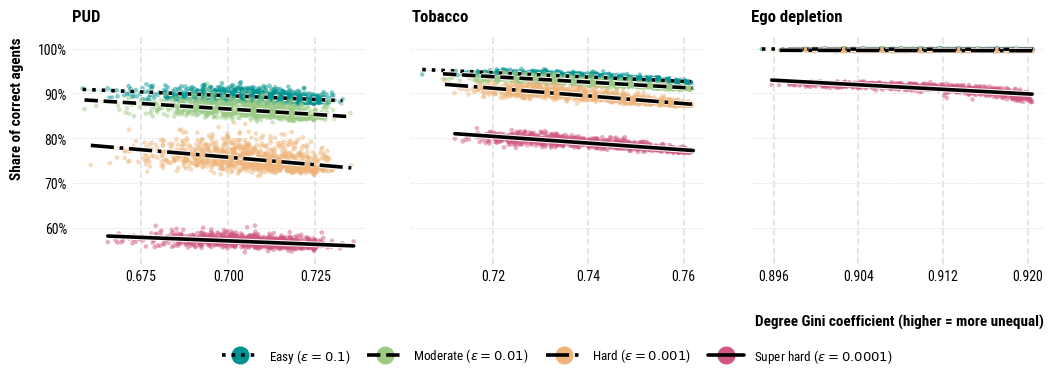

Colored dots: observed variant means. Black lines: adjusted predictions. Shading: pointwise 95% confidence intervals.
Clustering held at group means; confidence intervals clustered by actual variant identity. All four conditions have fixed easiness.
PNG: /Users/heinduijf/GitHub/e_network_inequality/results/figures/combined_conditions_regression_facets.png
SVG: /Users/heinduijf/GitHub/e_network_inequality/results/figures/combined_conditions_regression_facets.svg


In [87]:
from utils.equality_plots import plot_facets, finished_plot_previews

# Shared visual settings: edit these for both figure versions.
pooled_plot_cmap = cmaps.temps
pooled_zoom_steps = {'pud': 5, 'tobacco': 2.5, 'ego': 2}
pooled_plot_dir = Path(globals().get('FIGURE_DIR', pooled_root / 'results' / 'figures'))
colors = np.asarray(pooled_plot_cmap(np.linspace(0, 1, len(pooled_conditions))))
pooled_plot_styles = {
    condition: {
        'color': color, 'linestyle': linestyle,
        'label': rf'{label} ($\varepsilon={pooled_expected_easiness[condition]:g}$)',
    }
    for (condition, (_, label)), color, linestyle in zip(
        pooled_conditions.items(), colors, (':', '--', '-.', '-'),
    )
}

frames = []
for network in pooled_networks:
    for condition in pooled_conditions:
        group = f'{network}__{condition}'
        subset = pooled_data.loc[pooled_data['group'].eq(group)]
        if subset.empty:
            continue  # Missing groups have no fitted curve.
        gini = np.linspace(
            subset['degree_gini_coefficient'].min(),
            subset['degree_gini_coefficient'].max(), 160,
        )
        # Keep exactly the fitted design's column order. Other groups contribute zero.
        # Centered clustering equals zero at the relevant group's mean.
        design = pd.DataFrame(
            0.0, index=range(len(gini)), columns=pooled_X.columns,
        )
        design[f'{group}__intercept'] = 1.0
        design[f'{group}__gini'] = (
            gini - subset['degree_gini_coefficient'].mean()
        ) / 0.01
        # Each prediction is a linear combination of fitted coefficients. t_test
        # retains the model's clustered covariance AND cluster-based t degrees of freedom.
        prediction = pooled_model.t_test(design.to_numpy())
        interval = np.asarray(prediction.conf_int(alpha=0.05))
        frames.append(pd.DataFrame({
            'network': network,
            'condition': condition,
            'gini': gini,
            'mean_pp': np.asarray(prediction.effect).reshape(-1),
            'lower_pp': interval[:, 0],
            'upper_pp': interval[:, 1],
        }))
pooled_plot_predictions = pd.concat(frames, ignore_index=True)

pooled_plot_fig, pooled_plot_paths = plot_facets(
    pooled_data, pooled_plot_predictions, pooled_networks, pooled_plot_styles,
    style=OPINIONATED_STYLE,
    output_path=pooled_plot_dir / 'combined_conditions_regression_facets',
)

print('Colored dots: observed variant means. Black lines: adjusted predictions. Shading: pointwise 95% confidence intervals.')
print('Clustering held at group means; confidence intervals clustered by actual variant identity. All four conditions have fixed easiness.')
for row in pooled_coverage.loc[~pooled_coverage['status'].eq('complete')].itertuples():
    print(f'Incomplete download: {pooled_conditions[row.condition][1]} / {pooled_networks[row.network]}: '
          f'{row.variants_loaded:,} of {row.variants_expected} variants ({row.status}).')

for extension, path in pooled_plot_paths.items():
    print(f'{extension.upper()}: {path}')

### Finished-plot previews: grayscale and red–green color vision

These previews transform the **finished 300-dpi PNG from the preceding cell**, after the dots, confidence bands, legend, and text have been rendered and composited. They do not recolor the palette or rerun the regressions.

[Colorspacious](https://colorspacious.readthedocs.io/en/stable/tutorial.html#simulating-colorblindness) supplies the Machado et al. color-vision simulation. Both red–green types are shown at severity 100: **protanopia** and **deuteranopia**. These are simulated views of the existing figure, not replacement palettes. Grayscale preserves relative luminance by converting to linear sRGB before removing color.

Run the combined-plot cell first. Each preview keeps the original pixel dimensions and layout and is saved beside the original as a PNG with a `_grayscale`, `_protanopia`, or `_deuteranopia` suffix. Labels and notes are printed outside the images; the original PNG and SVG are preserved. To evaluate a different colormap, rerun the original plot and then this cell.

Black and white / grayscale


/Users/heinduijf/GitHub/e_network_inequality/utils/equality_plots.py:139: RuntimeWarning: divide by zero encountered in matmul
  luminance = linear @ np.array([0.2126, 0.7152, 0.0722])
/Users/heinduijf/GitHub/e_network_inequality/utils/equality_plots.py:139: RuntimeWarning: overflow encountered in matmul
  luminance = linear @ np.array([0.2126, 0.7152, 0.0722])
/Users/heinduijf/GitHub/e_network_inequality/utils/equality_plots.py:139: RuntimeWarning: invalid value encountered in matmul
  luminance = linear @ np.array([0.2126, 0.7152, 0.0722])


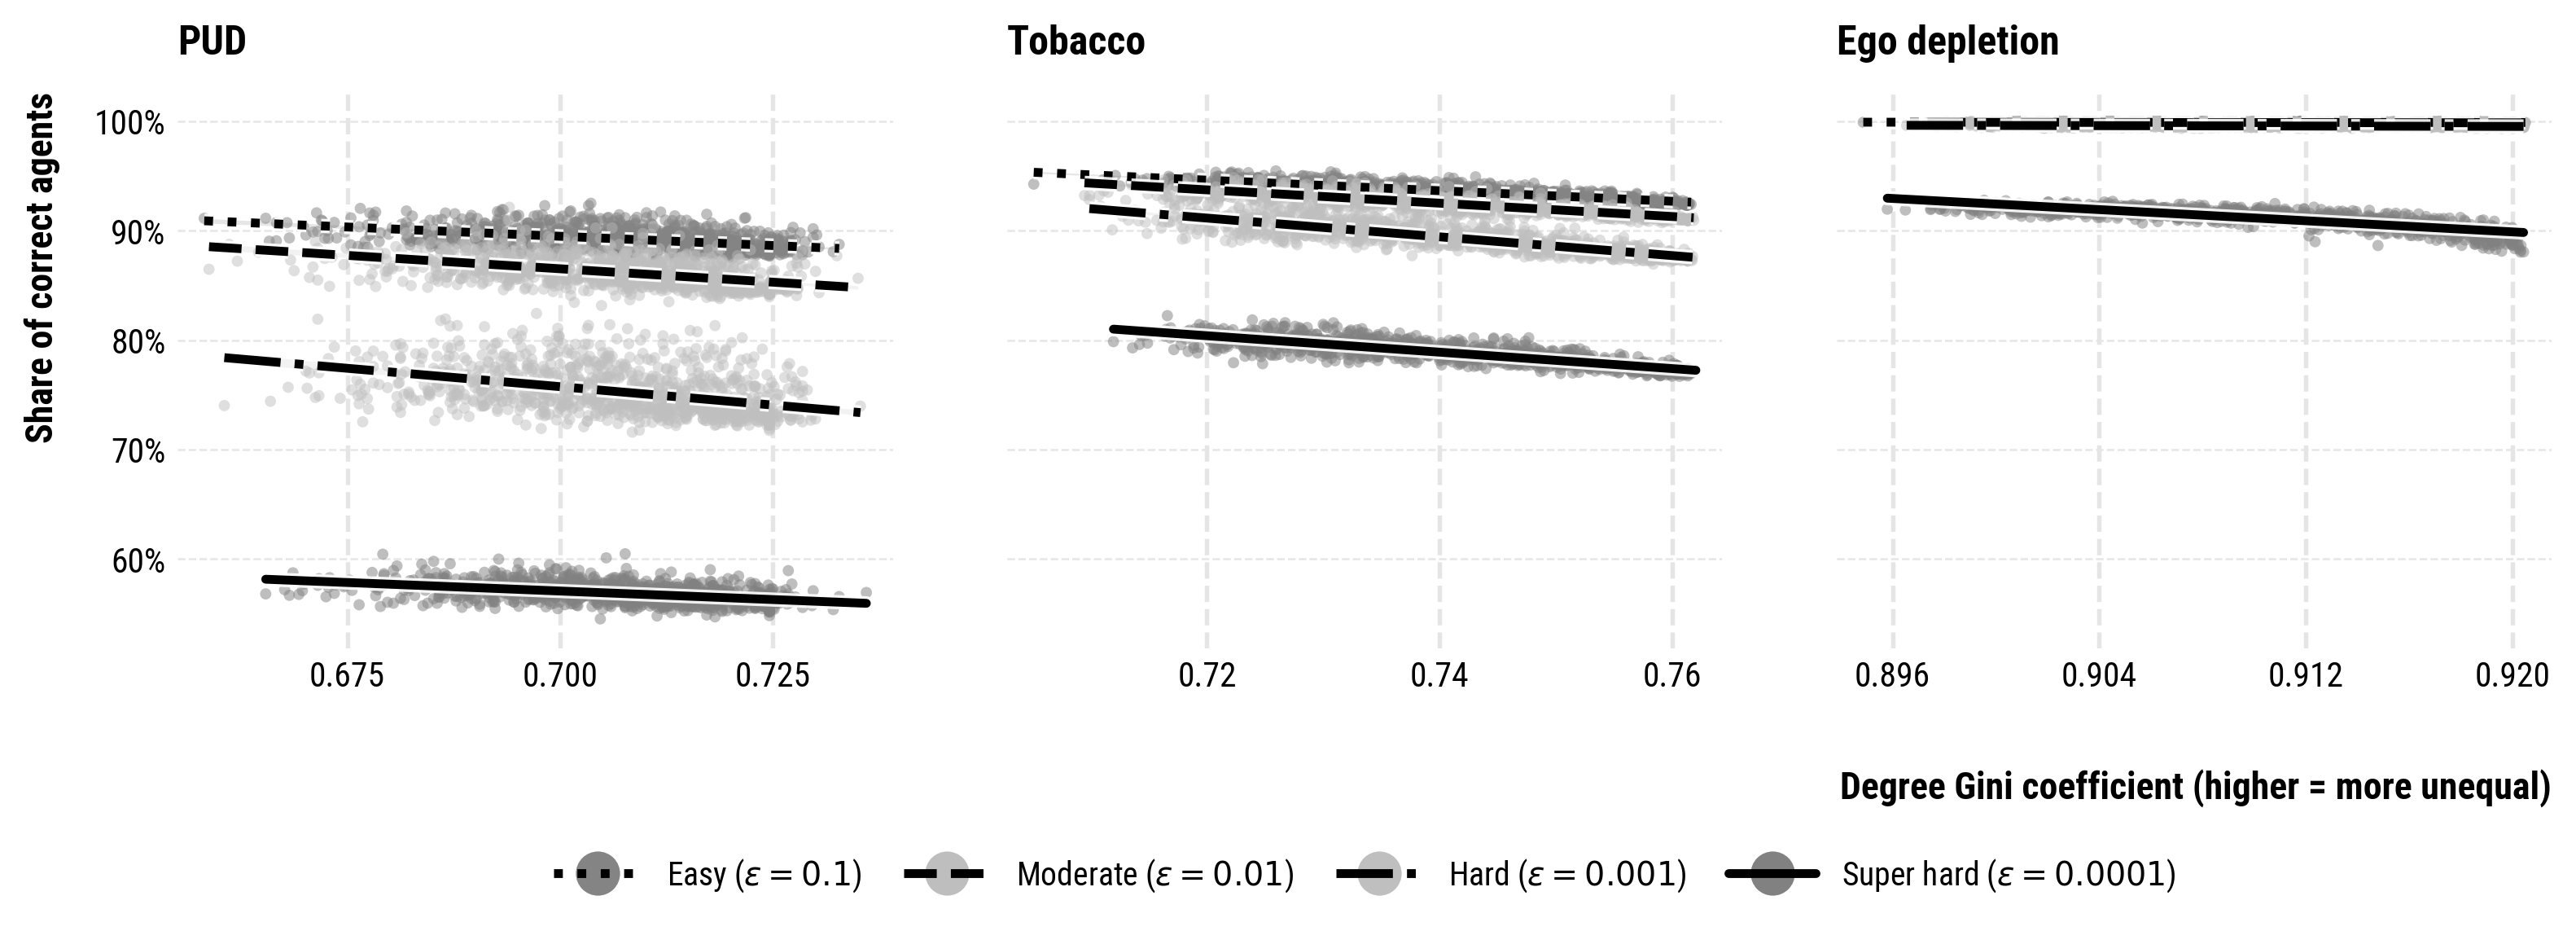

Saved: /Users/heinduijf/GitHub/e_network_inequality/results/figures/combined_conditions_regression_facets_grayscale.png
Protanopia simulation (full severity)


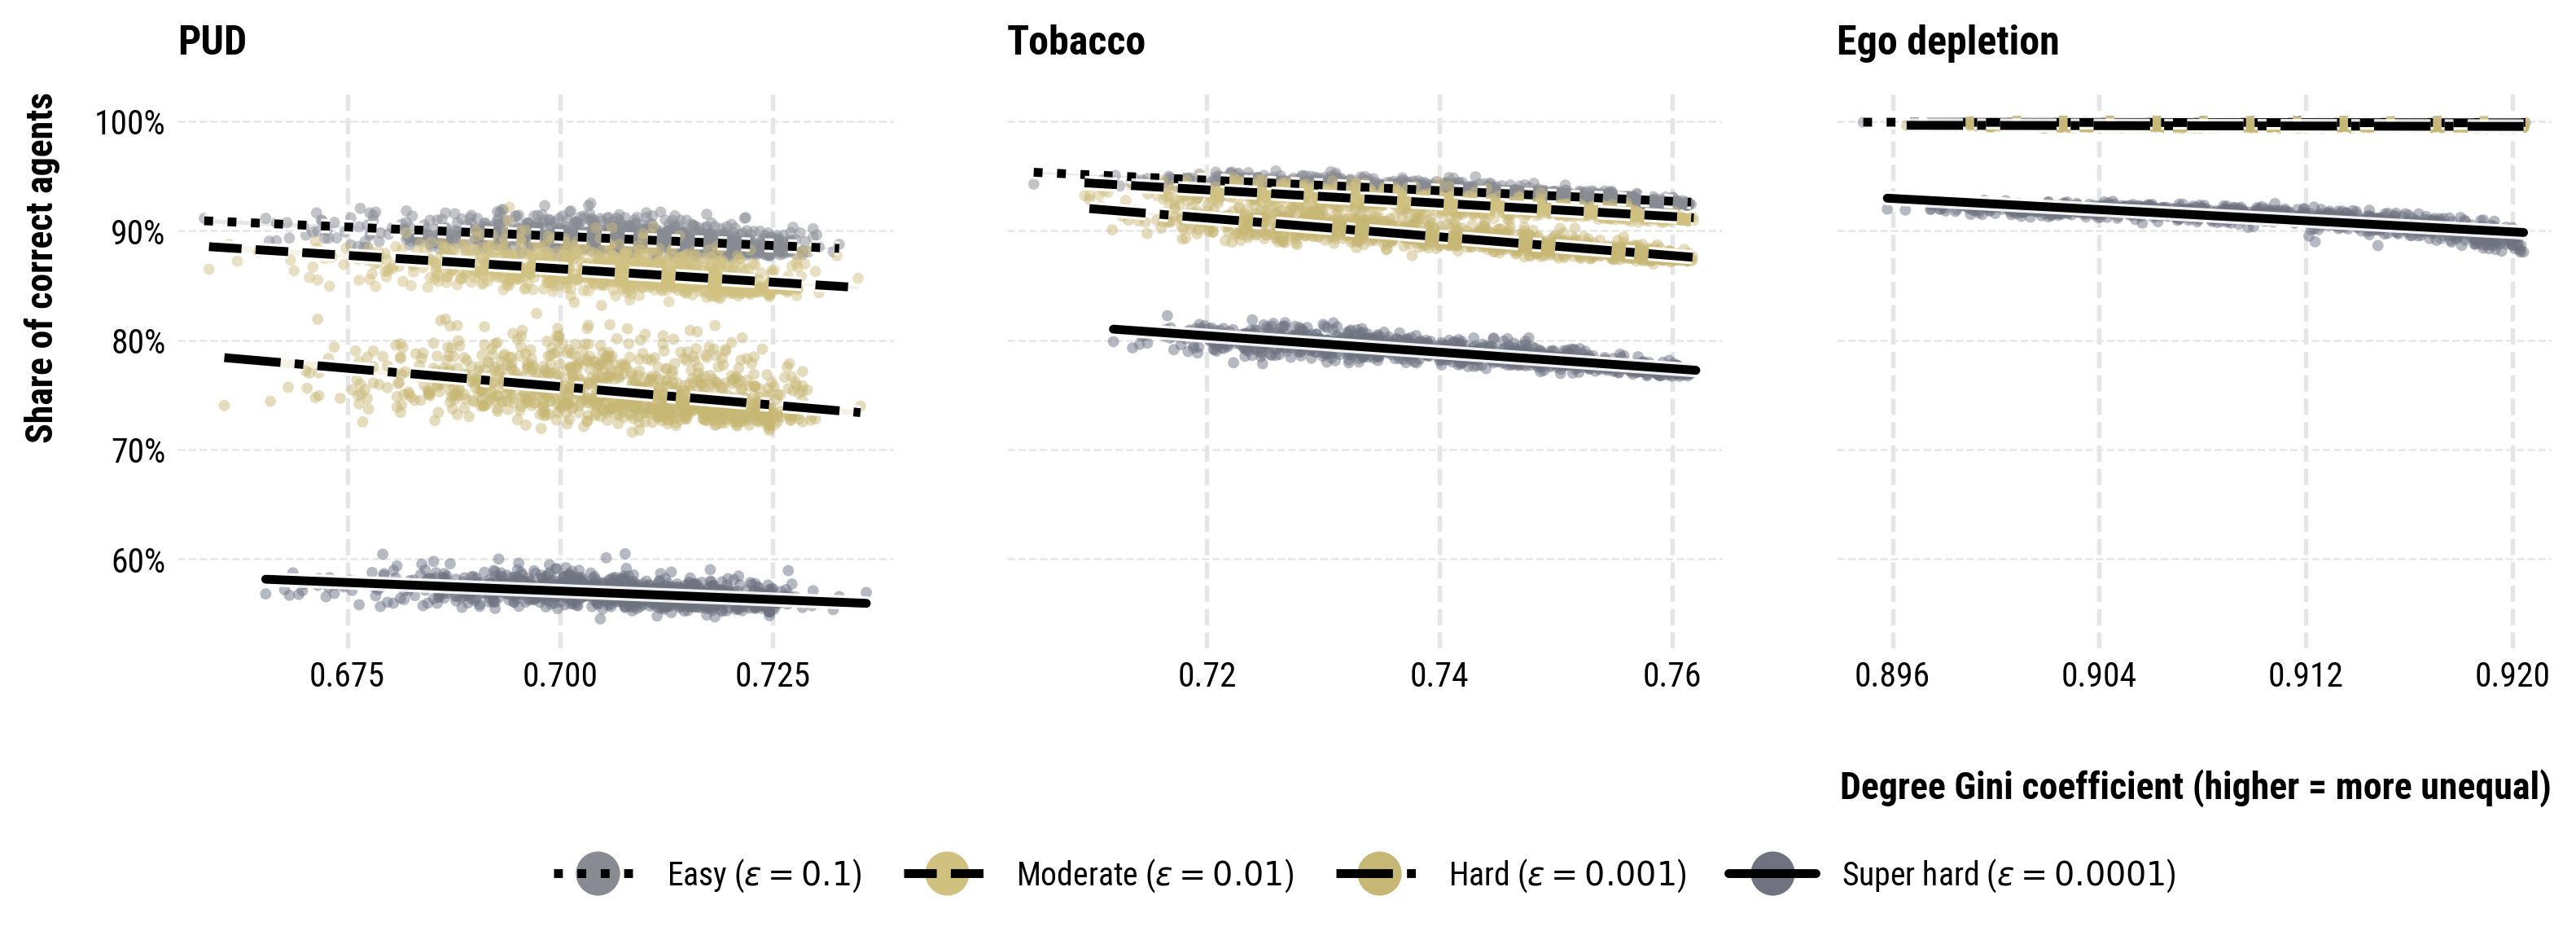

Saved: /Users/heinduijf/GitHub/e_network_inequality/results/figures/combined_conditions_regression_facets_protanopia.png
Deuteranopia simulation (full severity)


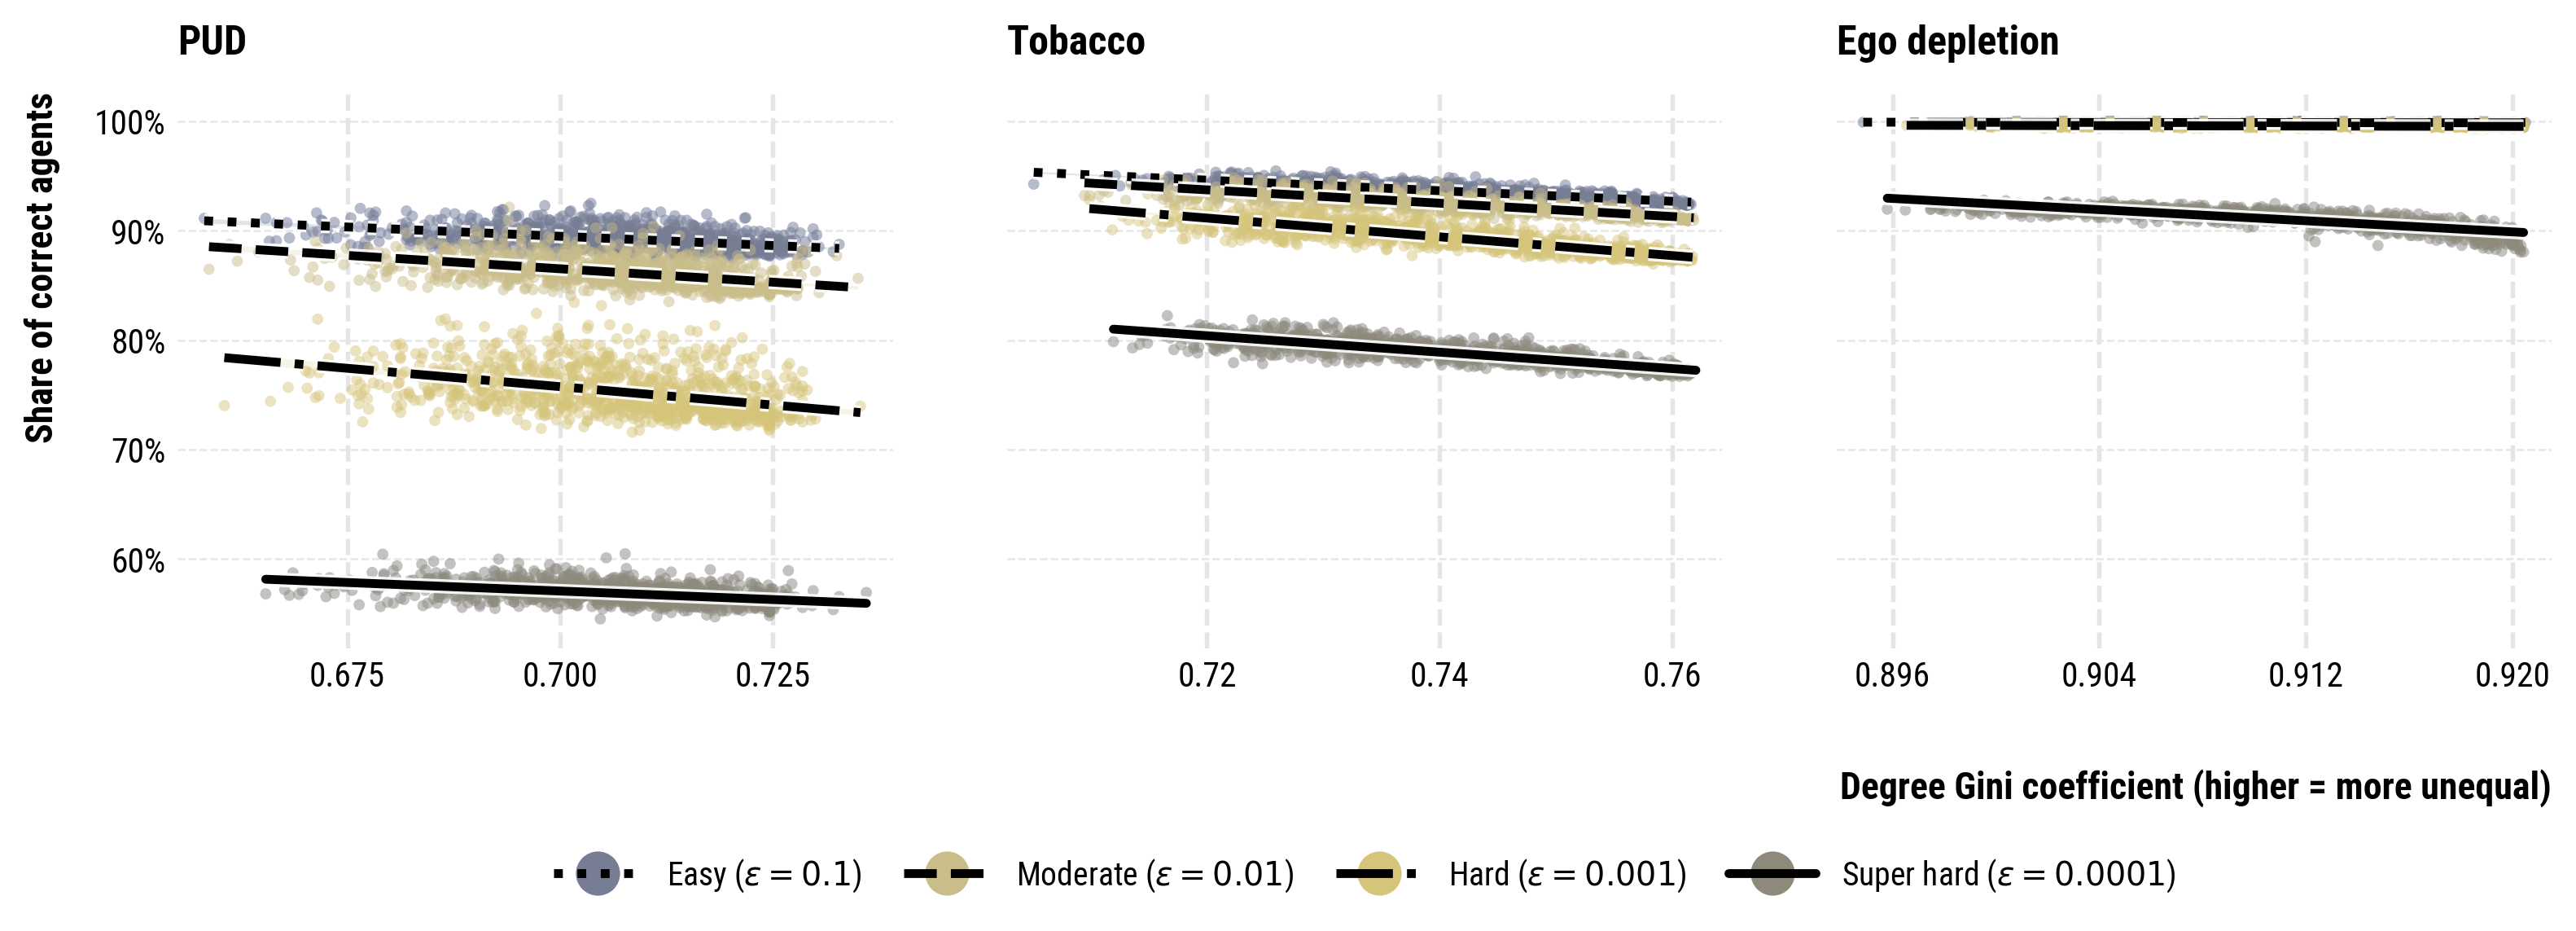

Saved: /Users/heinduijf/GitHub/e_network_inequality/results/figures/combined_conditions_regression_facets_deuteranopia.png
Transformations applied to the finished figure, including its legend and shading.


In [88]:
pooled_access_paths = finished_plot_previews(pooled_plot_paths['png'])


### Alternative figure: progressively zoomed vertical scales

The panels retain their PUD → Tobacco → Ego order, with tighter vertical ranges toward the right. Each range includes all that network's observed points and fitted confidence bands. All three panels have seven aligned tick rows, with 100% at the same height and equal proportional padding. The `pooled_zoom_steps` settings in the first plotting cell give smaller tick steps toward the right: 5 percentage points for PUD, 2.5 for Tobacco, and 2 for Ego in the current data. The ranges are nested and include all observations and confidence bands.

Soft gray diagonal shading appears only in the gaps between panels. It connects each next panel's vertical range on the preceding panel to the next panel's full height. The transitions are drawn behind the percentage labels, with no connector lines, outlines, or corner marks. The colored fitted-mean confidence intervals remain. **These guides compare vertical scales across different networks; the panels do not show the same observations.** Gini ranges remain specific to each network. Apparent slopes should therefore be interpreted using the tick labels; the common-scale figure above remains available for direct visual comparison.

All available conditions remain visible, including the partial super-hard Ego data near 90%. Missing super-hard PUD and Tobacco results remain omitted. The label stays bold and right-aligned, and the legend stays below the panels. The finished zoomed figure also gets grayscale, protanopia, and deuteranopia previews.

ValueError: Increase the zoom tick step for pud to include all data and CIs.

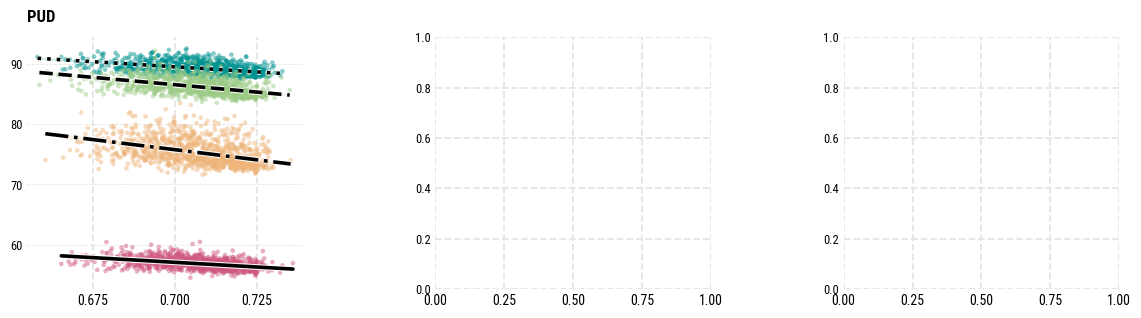

In [89]:
pooled_zoom_fig, pooled_zoom_paths = plot_facets(
    pooled_data, pooled_plot_predictions, pooled_networks, pooled_plot_styles,
    style=OPINIONATED_STYLE, zoom_steps=pooled_zoom_steps,
    output_path=pooled_plot_dir / 'combined_conditions_regression_facets_zoomed',
)

print('Y ticks and the 100% reference align across panels; numerical tick steps shrink to the right.')
print('Diagonal shading between facets shows how the next panel’s y range expands.')
print('The panels show different networks; the shading compares only vertical scales. All available points and fitted bands are retained.')
for ax, title in zip(pooled_zoom_fig.axes, pooled_networks.values()):
    low, high = ax.get_ylim()
    print(f'{title}: {low:.1f}%–{high:.1f}%')
print('Super-hard data remain incomplete: Ego has 864 variants; PUD and Tobacco have none in this download.')
for extension, path in pooled_zoom_paths.items():
    print(f'{extension.upper()}: {path}')


Zoomed figure — Black and white / grayscale


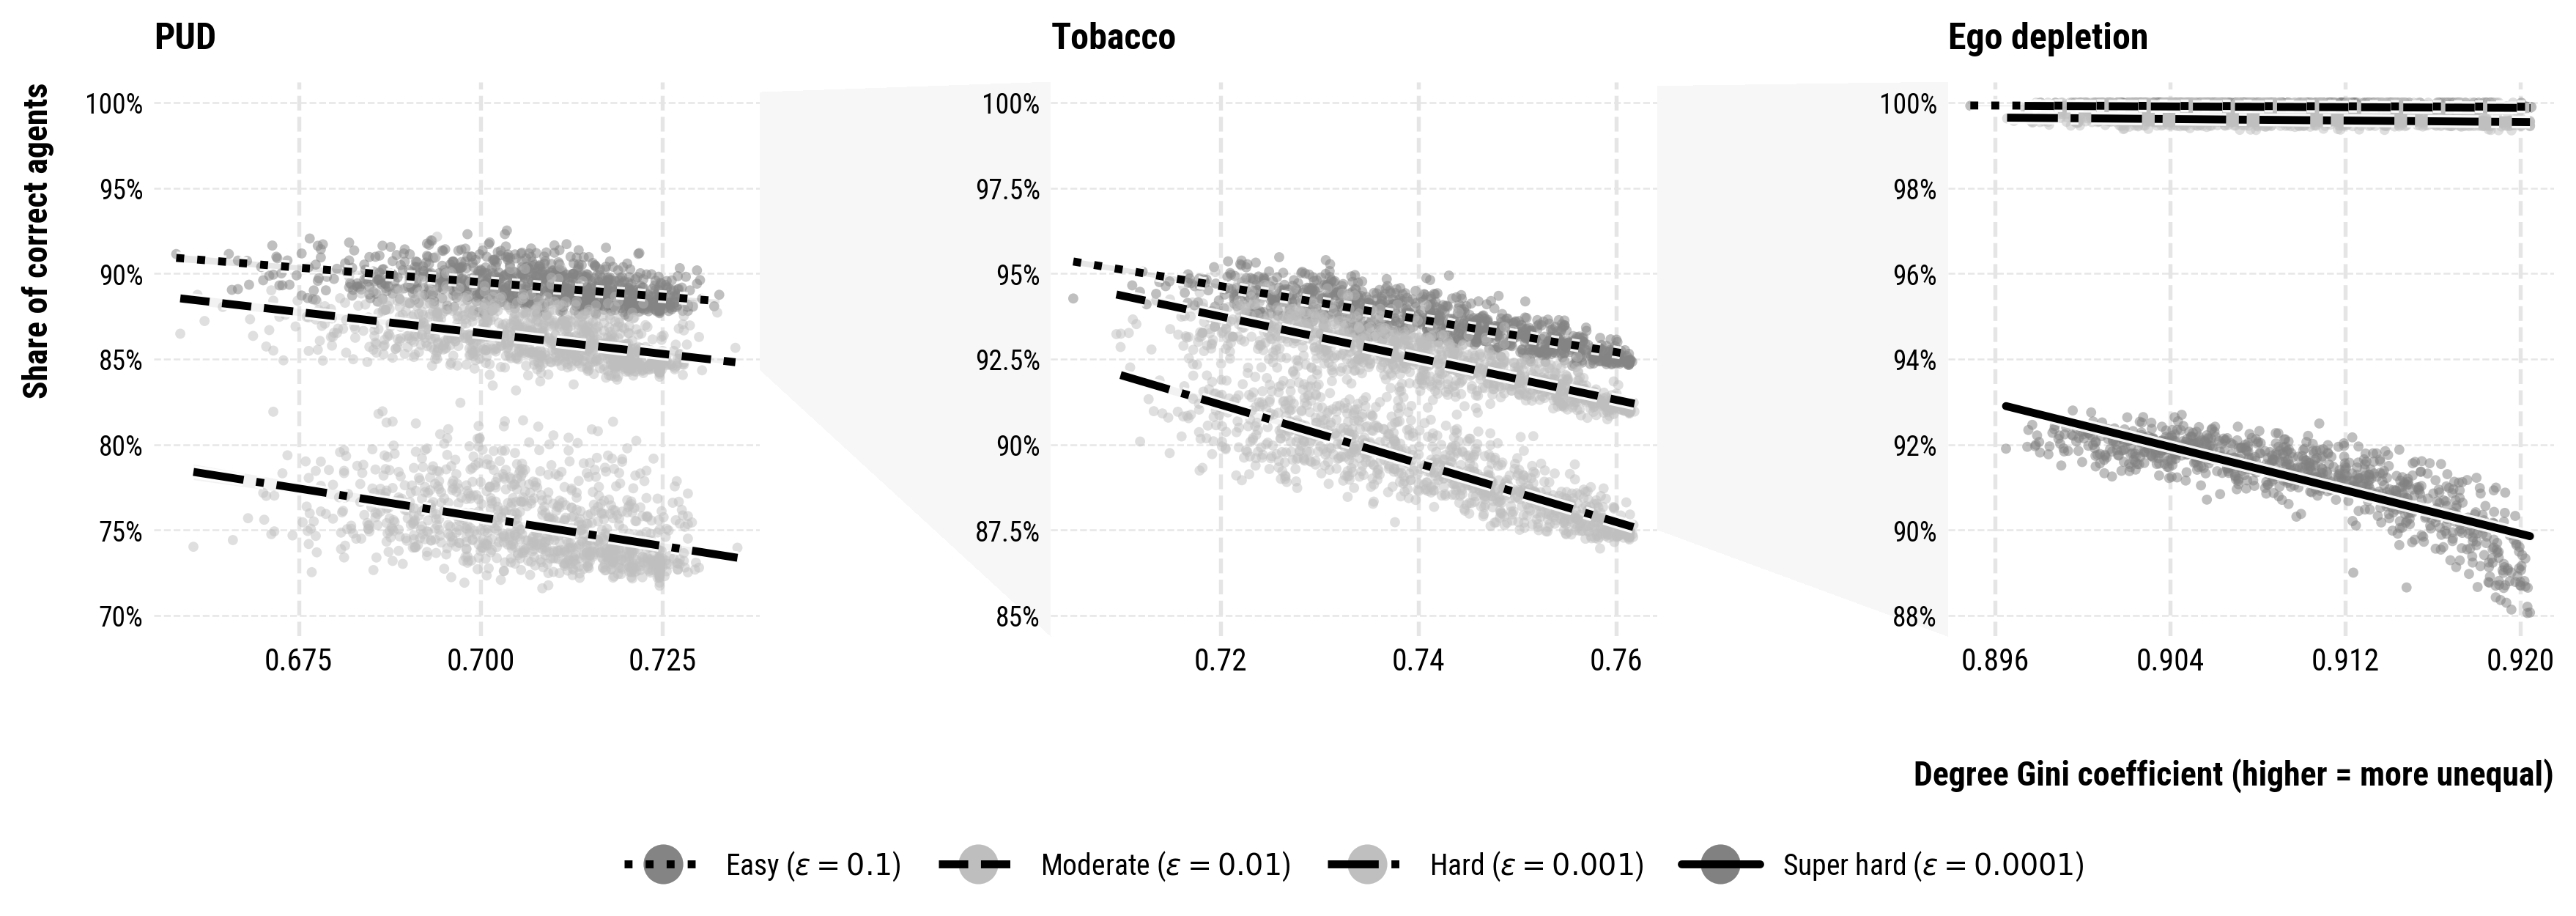

Saved: /Users/Noich001/Desktop/e_network_inequality-1/results/figures/combined_conditions_regression_facets_zoomed_grayscale.png
Zoomed figure — Protanopia simulation (full severity)


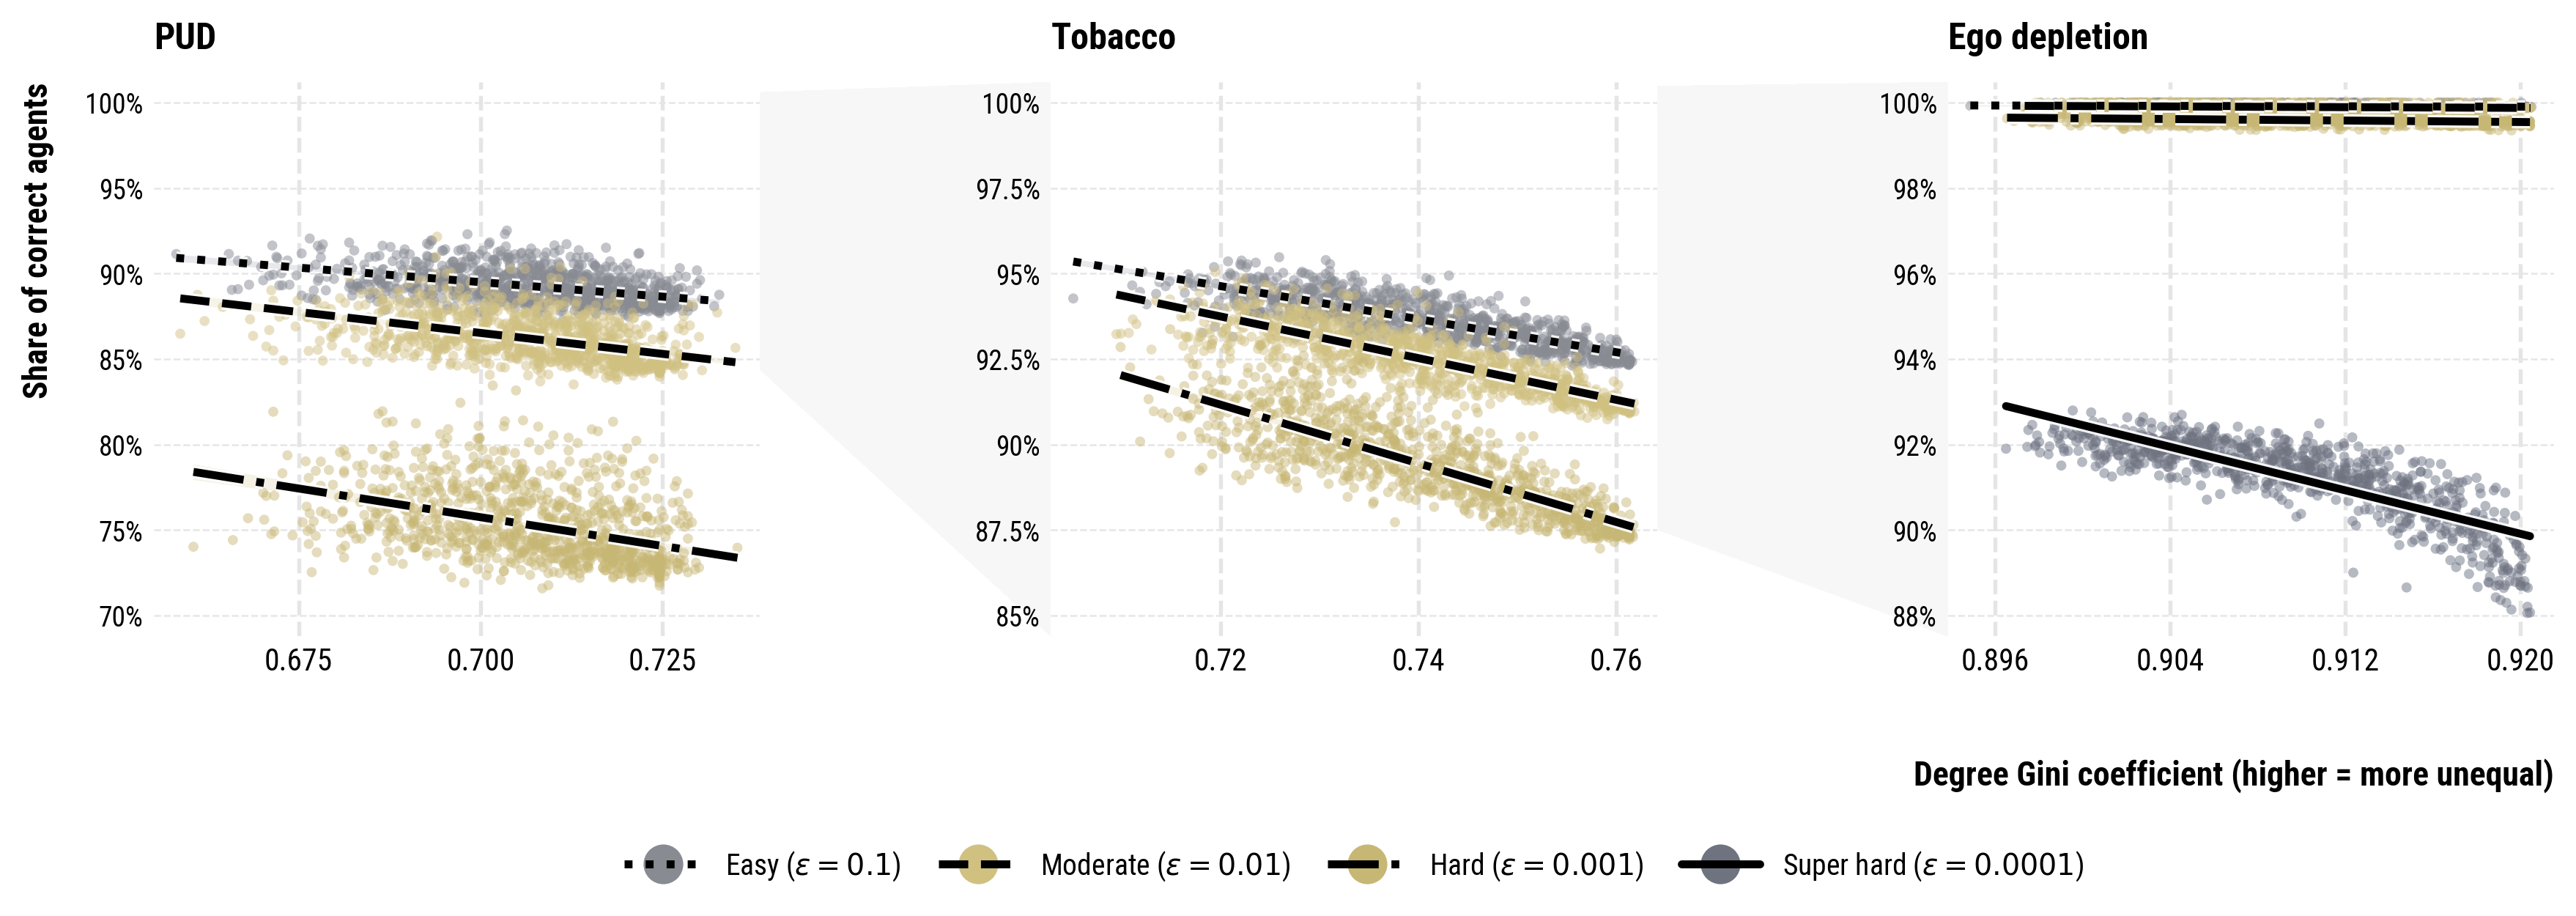

Saved: /Users/Noich001/Desktop/e_network_inequality-1/results/figures/combined_conditions_regression_facets_zoomed_protanopia.png
Zoomed figure — Deuteranopia simulation (full severity)


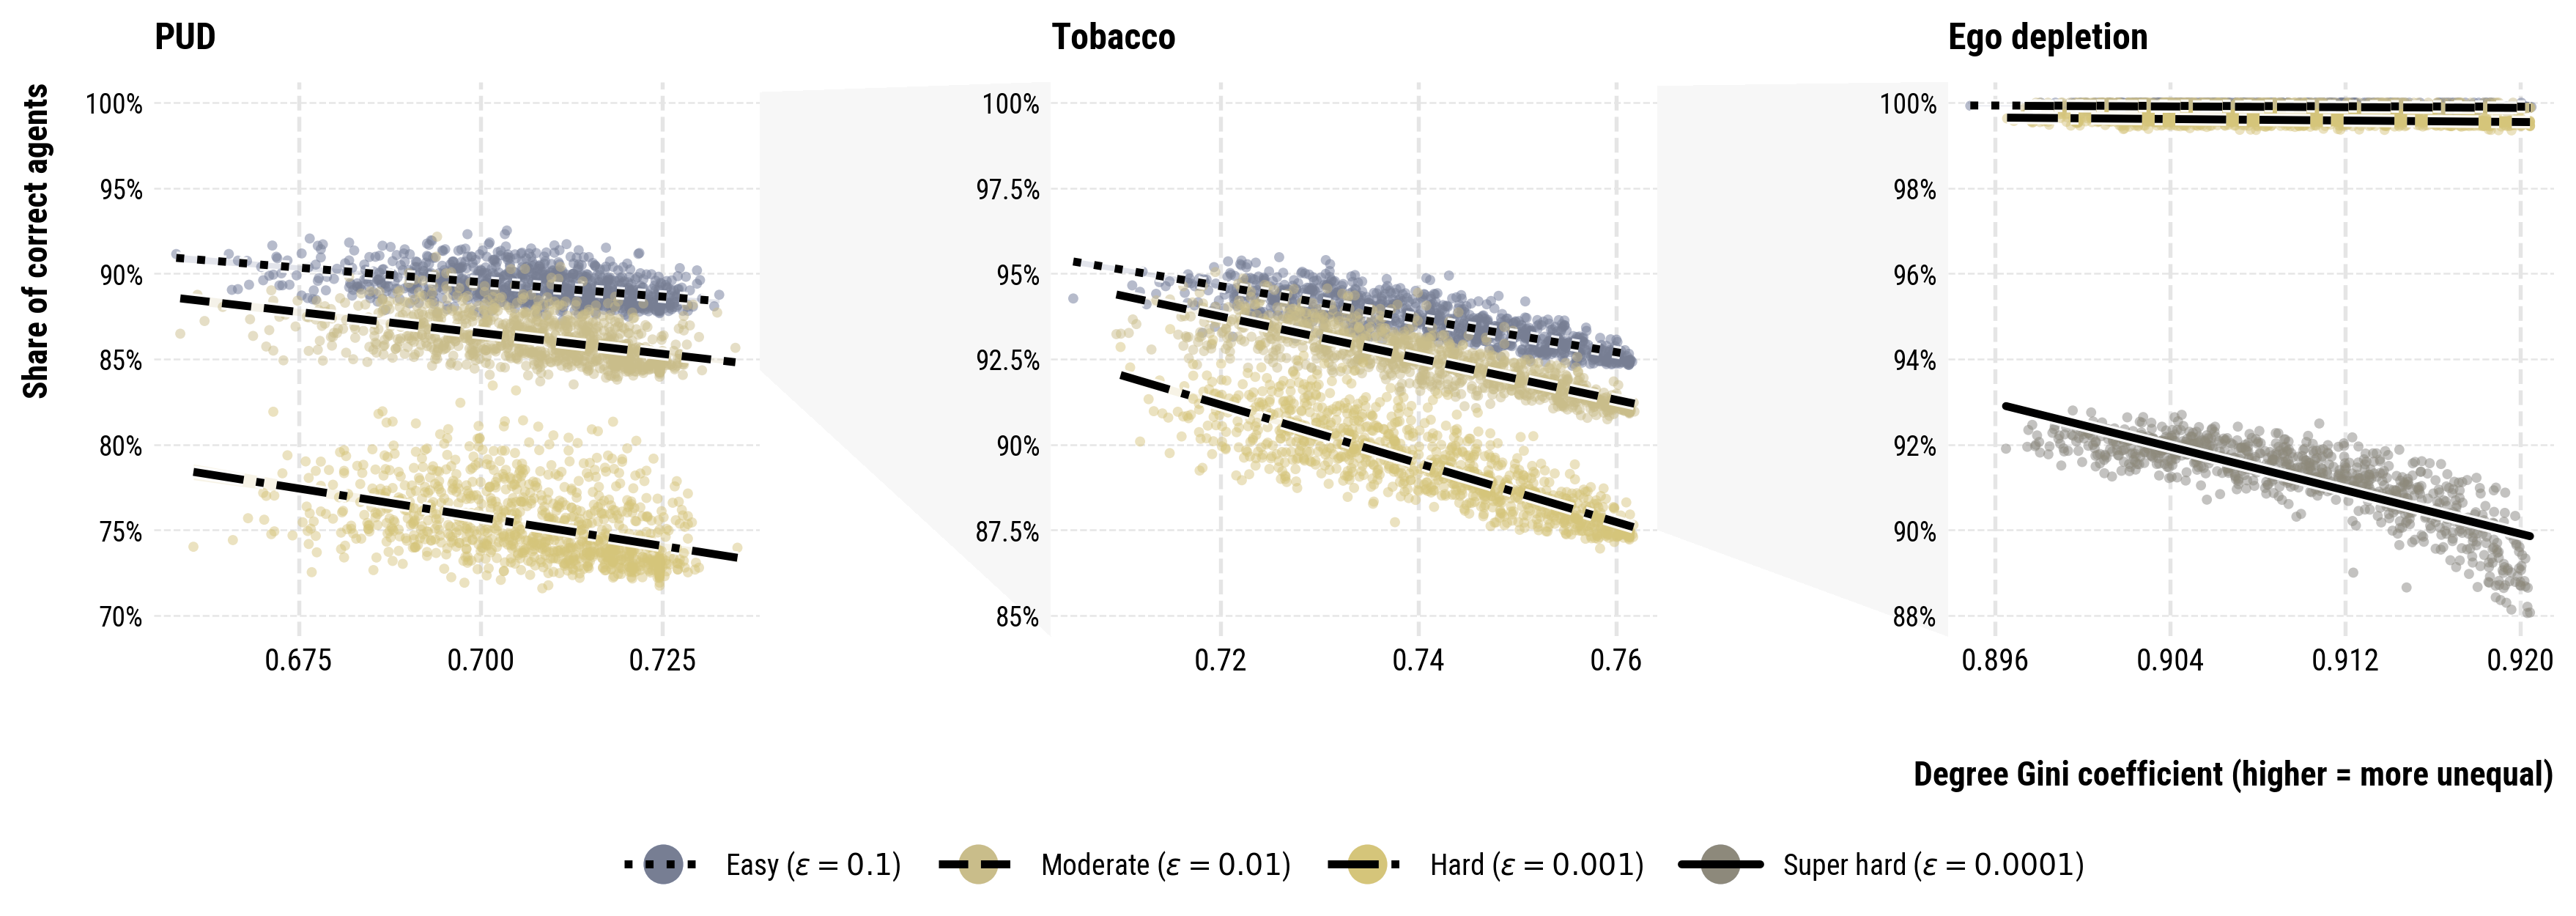

Saved: /Users/Noich001/Desktop/e_network_inequality-1/results/figures/combined_conditions_regression_facets_zoomed_deuteranopia.png
Transformations applied to the finished figure, including its legend and shading.


In [ ]:
pooled_zoom_access_paths = finished_plot_previews(pooled_zoom_paths['png'], prefix='Zoomed figure — ')
